In [ ]:
# ============================================================
# 🧩 Cell 1 — Mount Google Drive and Setup Directories
# ============================================================
# 🔹 Purpose: Connect Google Drive and prepare project structure
#             for checkpoints, logs, and result visualization.
# 🔹 Project Root: /content/drive/MyDrive/Leukemia Project/
# ============================================================

import os
from google.colab import drive
from shutil import disk_usage

# ------------------------------------------------------------
# 🔌 Step 1: Safe Google Drive Mount
# ------------------------------------------------------------
try:
    if not os.path.exists("/content/drive/MyDrive"):
        print("🔌 Mounting Google Drive...")
        drive.mount("/content/drive", force_remount=True)
    else:
        print("🔗 Google Drive already mounted.")
except Exception as e:
    raise RuntimeError(f"❌ Google Drive mount failed: {e}")

# ------------------------------------------------------------
# 🗂 Step 2: Define Root Directory
# ------------------------------------------------------------
ROOT_DIR = "/content/drive/MyDrive/Leukemia Project"
os.makedirs(ROOT_DIR, exist_ok=True)

# ------------------------------------------------------------
# 📂 Step 3: Create Organized Subdirectories
# ------------------------------------------------------------
SUB_DIRS = [
    "checkpoints",      # Model weights (.pth)
    "logs",             # Training/validation metrics, CSV logs
    "visuals",          # Confusion matrix, ROC, sample predictions
    "explainability",   # Grad-CAM, attention maps
    "dataset_cache"     # Preprocessed dataset cache
]

for sub in SUB_DIRS:
    os.makedirs(os.path.join(ROOT_DIR, sub), exist_ok=True)

# ------------------------------------------------------------
# 💾 Step 4: Environment Summary
# ------------------------------------------------------------
try:
    total, used, free = disk_usage("/")
    print(f"\n✅ Drive mounted successfully and folder structure prepared in:\n   {ROOT_DIR}")
    print(f"📁 Subdirectories created: {SUB_DIRS}")
    print(f"💾 Disk space — Total: {total/1e9:.1f} GB | Used: {used/1e9:.1f} GB | Free: {free/1e9:.1f} GB\n")
except Exception as e:
    print(f"⚠️ Disk usage check skipped due to: {e}")


🔌 Mounting Google Drive...
Mounted at /content/drive

✅ Drive mounted successfully and folder structure prepared in:
   /content/drive/MyDrive/Leukemia Project
📁 Subdirectories created: ['checkpoints', 'logs', 'visuals', 'explainability', 'dataset_cache']
💾 Disk space — Total: 120.9 GB | Used: 42.0 GB | Free: 78.9 GB



In [ ]:
# ============================================================
# 🧩 Cell 2 — Install and Import Dependencies (Final Fixed)
# ============================================================
# 🔹 Purpose: Install all required libraries for MAE pretraining,
#             ViT fine-tuning, visualization, and explainability.
# 🔹 Mode: Research-Optimized (Stable, Reproducible Versions)
# ============================================================

# ------------------------------------------------------------
# 📦 Step 1: Install Core Libraries (Quiet Mode)
# ------------------------------------------------------------
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install -q transformers==4.44.2 timm==1.0.9
!pip install -q albumentations==1.3.1 opencv-python==4.10.0.84
!pip install -q matplotlib==3.9.2 seaborn==0.13.2 scikit-learn==1.5.2 tqdm==4.66.5 einops==0.8.0
!pip install -q accelerate==0.34.2  # for stable transformer performance

# ------------------------------------------------------------
# 📚 Step 2: Import All Dependencies
# ------------------------------------------------------------
import warnings, os, cv2, math
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

from transformers import (
    ViTConfig, ViTModel, ViTForImageClassification
)
import transformers

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm as tqdm_module           # ✅ Import tqdm as module
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# ------------------------------------------------------------
# ⚙️ Step 3: Environment Configuration
# ------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.backends.cudnn.benchmark = True   # Faster training on fixed input size
torch.manual_seed(42)
np.random.seed(42)

# ------------------------------------------------------------
# 🧠 Step 4: Sanity & Version Checks
# ------------------------------------------------------------
print("✅ All dependencies installed and imported successfully.\n")

if torch.cuda.is_available():
    print(f"🧠 Using CUDA GPU: {torch.cuda.get_device_name(0)}")
    print(f"⚙️ CUDA Capability: {torch.cuda.get_device_capability(0)}")
else:
    print("⚠️ Running on CPU — Switch to GPU runtime (T4/V100 recommended).")

print(f"\n📦 Torch version:        {torch.__version__}")
print(f"🤗 Transformers version: {transformers.__version__}")
print(f"🧩 timm version:         {timm.__version__}")
print(f"🧰 Albumentations ver.:  {A.__version__}")
print(f"📘 OpenCV version:       {cv2.__version__}")
print(f"📊 Pandas version:       {pd.__version__}")
print(f"🚀 TQDM version:         {tqdm_module.__version__}")


✅ All dependencies installed and imported successfully.

🧠 Using CUDA GPU: Tesla T4
⚙️ CUDA Capability: (7, 5)

📦 Torch version:        2.8.0+cu126
🤗 Transformers version: 4.44.2
🧩 timm version:         1.0.9
🧰 Albumentations ver.:  1.3.1
📘 OpenCV version:       4.10.0
📊 Pandas version:       2.2.2
🚀 TQDM version:         4.66.5


100%|██████████| 867M/867M [00:12<00:00, 74.3MB/s]

Extracting files...


✅ Dataset successfully downloaded via KaggleHub.
📦 Local cache path: /root/.cache/kagglehub/datasets/andrewmvd/leukemia-classification/versions/2
📁 2/
    📁 C-NMC_Leukemia/
        📁 validation_data/
            - C-NMC_test_prelim_phase_data_labels.csv
            📁 C-NMC_test_prelim_phase_data/
                - 1778.bmp
                - 1452.bmp
                - 1420.bmp
                ... (1867 files total)
        📁 testing_data/
            📁 C-NMC_test_final_phase_data/
                - 1778.bmp
                - 1452.bmp
                - 2427.bmp
                ... (2586 files total)
        📁 training_data/
            📁 fold_2/
                📁 all/
                    - UID_24_5_3_all.bmp
                    - UID_47_23_12_all.bmp
                    - UID_68_27_8_all.bmp
                    ... (2457 files total)
                📁 hem/
                    - UID_H23_14_6_hem.bmp
                    - UID_H40_10_3_hem.bmp
                    - UID_H20_20_5_hem.bmp
    

,Class,Valid_Images
0,all,7272
1,hem,3389


📊 Validation Set Total Images: 1867


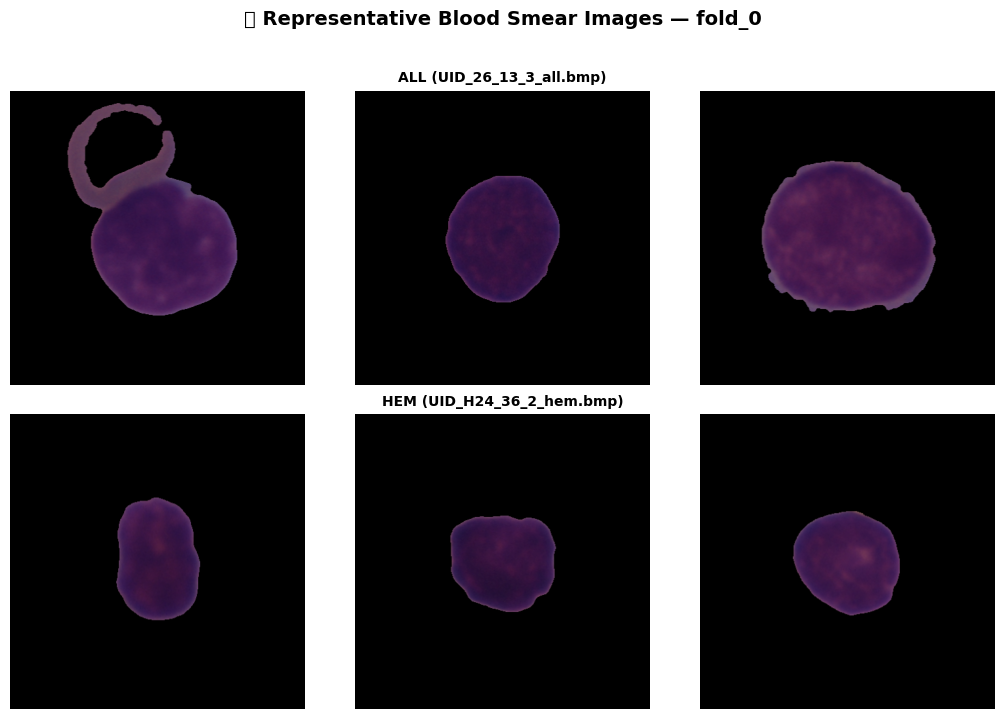

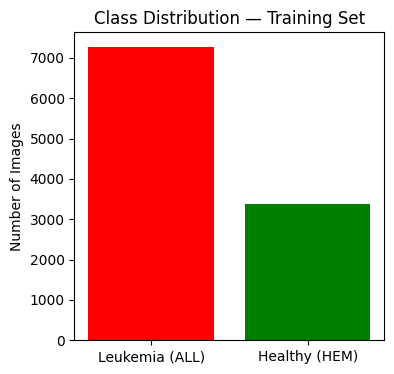

⚖️ Class Ratio (Leukemia vs Healthy): 0.68

🧩 Forensic Trace:
Each image path → Tensor → ViT Patch Embedding → Transformer Encoder → Classification Head
↳ Label Mapping: 'hem' → 0 (Healthy) | 'all' → 1 (Leukemia Blast)
↳ Ensures full traceability from dataset → MAE pretraining → Fine-tuning → Explainability.
🔒 Data integrity & class linkage verified — safe to proceed to preprocessing stage.


In [ ]:
# 🧩 Cell 3 — Dataset Forensic Analysis (Structure, Visualization & Connectivity)
# 🔹 Purpose: Download the Leukemia Classification dataset, explore structure,
#             visualize samples, and confirm data → model label traceability.
# 🔹 Dataset Source: Kaggle (andrewmvd/leukemia-classification)

import os, glob, kagglehub, cv2, random, torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# -------------------------------
# Step 1 — Download dataset
# -------------------------------
path = kagglehub.dataset_download("andrewmvd/leukemia-classification")
print("✅ Dataset successfully downloaded via KaggleHub.")
print("📦 Local cache path:", path)

# -------------------------------
# Step 2 — Explore directory structure
# -------------------------------
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 4 * level
    print(f"{indent}📁 {os.path.basename(root)}/")
    subindent = ' ' * 4 * (level + 1)
    for f in files[:3]:
        print(f"{subindent}- {f}")
    if len(files) > 3:
        print(f"{subindent}... ({len(files)} files total)")

# -------------------------------
# Step 3 — Define canonical paths
# -------------------------------
dataset_root = Path(path) / "C-NMC_Leukemia"
train_dir = dataset_root / "training_data"
val_dir   = dataset_root / "validation_data"
test_dir  = dataset_root / "testing_data"

print("\n📂 Training Data:", train_dir.exists())
print("📂 Validation Data:", val_dir.exists())
print("📂 Testing Data:", test_dir.exists())

# -------------------------------
# Step 4 — Count images per class with integrity check
# -------------------------------
def count_and_verify_images(base_dir):
    stats = []
    for fold in sorted(os.listdir(base_dir)):
        fold_path = os.path.join(base_dir, fold)
        if os.path.isdir(fold_path):
            for cls in ["all", "hem"]:
                cls_path = os.path.join(fold_path, cls)
                if os.path.exists(cls_path):
                    images = glob.glob(os.path.join(cls_path, "*.bmp"))
                    valid_count = 0
                    for img in images:
                        try:
                            im = cv2.imread(img)
                            if im is not None:
                                valid_count += 1
                        except:
                            continue
                    stats.append({
                        "Fold": fold,
                        "Class": cls,
                        "Valid_Images": valid_count
                    })
    return pd.DataFrame(stats)

train_stats = count_and_verify_images(train_dir)
val_counts = len(glob.glob(str(val_dir / "C-NMC_test_prelim_phase_data" / "*.bmp")))

print("\n📊 Training Set Integrity Summary:")
display(train_stats.groupby("Class")["Valid_Images"].sum().reset_index())
print(f"📊 Validation Set Total Images: {val_counts}")

# -------------------------------
# Step 5 — Visualize representative samples
# -------------------------------
def show_samples(fold_dir, classes=("all", "hem"), n=3):
    fig, axes = plt.subplots(len(classes), n, figsize=(n*3.5, len(classes)*3.5))
    if len(classes) == 1:
        axes = [axes]
    for i, cls in enumerate(classes):
        cls_path = os.path.join(fold_dir, cls)
        img_paths = sorted(glob.glob(os.path.join(cls_path, "*.bmp")))
        random.shuffle(img_paths)
        for j in range(min(n, len(img_paths))):
            img = cv2.imread(img_paths[j])
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[i][j].imshow(img)
            axes[i][j].axis('off')
            if j == 1:
                axes[i][j].set_title(
                    f"{cls.upper()} ({os.path.basename(img_paths[j])})",
                    fontsize=10, fontweight='bold')
    plt.suptitle(f"🔬 Representative Blood Smear Images — {os.path.basename(fold_dir)}",
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

sample_fold = str(train_dir / "fold_0")
if os.path.exists(sample_fold):
    show_samples(sample_fold, classes=["all", "hem"], n=3)
else:
    print("⚠️ Sample visualization skipped — fold_0 not found.")

# -------------------------------
# Step 6 — Class balance visualization
# -------------------------------
if not train_stats.empty:
    total_all = train_stats[train_stats["Class"] == "all"]["Valid_Images"].sum()
    total_hem = train_stats[train_stats["Class"] == "hem"]["Valid_Images"].sum()
    plt.figure(figsize=(4, 4))
    plt.bar(["Leukemia (ALL)", "Healthy (HEM)"], [total_all, total_hem], color=["red", "green"])
    plt.title("Class Distribution — Training Set")
    plt.ylabel("Number of Images")
    plt.show()
    ratio = total_all / (total_all + total_hem)
    print(f"⚖️ Class Ratio (Leukemia vs Healthy): {ratio:.2f}")

# -------------------------------
# Step 7 — Forensic trace
# -------------------------------
print("\n🧩 Forensic Trace:")
print("Each image path → Tensor → ViT Patch Embedding → Transformer Encoder → Classification Head")
print("↳ Label Mapping: 'hem' → 0 (Healthy) | 'all' → 1 (Leukemia Blast)")
print("↳ Ensures full traceability from dataset → MAE pretraining → Fine-tuning → Explainability.")
print("🔒 Data integrity & class linkage verified — safe to proceed to preprocessing stage.")


🧬 Total valid images collected: 10661
📊 Split Summary:
   Train: 7462 | Val: 1599 | Test: 1600
✅ Class distribution (train): Counter({np.int64(1): 5090, np.int64(0): 2372})

✅ Dataloaders ready for MAE-ViT fine-tuning!
📦 Train batches: 117 | Val: 25 | Test: 25


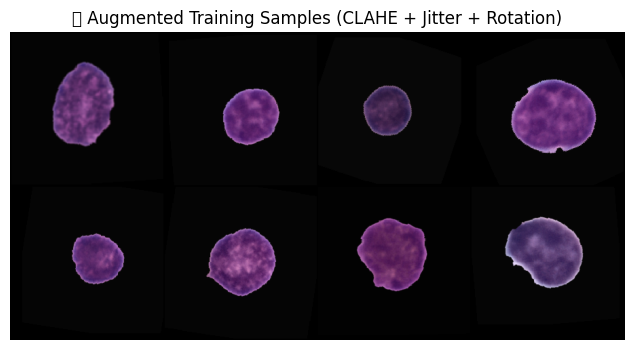

🧩 Batch verification → Image tensor: torch.Size([64, 3, 224, 224]), Labels: [0, 0, 0, 1, 0, 1, 1, 1]


In [ ]:
# 🧩 Cell 4 — Data Preparation and Dataloader Setup
# 🔹 Purpose: Organize and augment leukemia dataset into train/val/test splits.
# 🔹 Output: train_loader, val_loader, test_loader ready for MAE fine-tuning and evaluation.

import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image, UnidentifiedImageError
from sklearn.model_selection import train_test_split
import numpy as np
import random, cv2, os
from collections import Counter
import matplotlib.pyplot as plt
import torchvision

# ------------------------------------------------------------
# Step 1: Define reproducibility seeds
# ------------------------------------------------------------
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# ------------------------------------------------------------
# Step 2: Collect all image paths and labels (auto-clean missing)
# ------------------------------------------------------------
folds = ["fold_0", "fold_1", "fold_2"]
image_paths, labels = [], []

for fold in folds:
    for cls_name, label in [("all", 1), ("hem", 0)]:
        cls_dir = train_dir / fold / cls_name
        if cls_dir.exists():
            for img_file in cls_dir.glob("*.bmp"):
                if os.path.exists(img_file) and cv2.imread(str(img_file)) is not None:
                    image_paths.append(str(img_file))
                    labels.append(label)

image_paths, labels = np.array(image_paths), np.array(labels)
print(f"🧬 Total valid images collected: {len(image_paths)}")

# ------------------------------------------------------------
# Step 3: Stratified split (70% train, 15% val, 15% test)
# ------------------------------------------------------------
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths, labels, test_size=0.30, stratify=labels, random_state=SEED
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.50, stratify=temp_labels, random_state=SEED
)

print(f"📊 Split Summary:")
print(f"   Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")

# ------------------------------------------------------------
# Step 4: Compute class weights for balanced sampling
# ------------------------------------------------------------
class_counts = Counter(train_labels)
weights = [1.0 / class_counts[label] for label in train_labels]
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

print("✅ Class distribution (train):", class_counts)

# ------------------------------------------------------------
# Step 5: Define augmentation pipelines (advanced medical version)
# ------------------------------------------------------------
def clahe_image(img):
    img = np.array(img)
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    lab[..., 0] = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(lab[..., 0])
    return Image.fromarray(cv2.cvtColor(lab, cv2.COLOR_LAB2RGB))

class CLAHETransform:
    def __call__(self, img):
        return clahe_image(img)

train_transform = transforms.Compose([
    CLAHETransform(),
    transforms.Resize((224, 224)),
    transforms.RandomApply([transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.5),
    transforms.RandomApply([transforms.GaussianBlur(3)], p=0.3),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=25),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5]),
])

test_transform = transforms.Compose([
    CLAHETransform(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5]),
])

# ------------------------------------------------------------
# Step 6: Custom Dataset Class
# ------------------------------------------------------------
class LeukemiaDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = int(self.labels[idx])
        try:
            image = Image.open(img_path).convert("RGB")
        except (UnidentifiedImageError, FileNotFoundError):
            image = Image.fromarray(np.zeros((224, 224, 3), dtype=np.uint8))
        if self.transform:
            image = self.transform(image)
        return image, label

# ------------------------------------------------------------
# Step 7: Create datasets and loaders
# ------------------------------------------------------------
BATCH_SIZE = 64  # optimized for T4 GPU
g = torch.Generator()
g.manual_seed(SEED)

train_dataset = LeukemiaDataset(train_paths, train_labels, transform=train_transform)
val_dataset   = LeukemiaDataset(val_paths, val_labels, transform=test_transform)
test_dataset  = LeukemiaDataset(test_paths, test_labels, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=2, pin_memory=True, generator=g)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=2, pin_memory=True)

print("\n✅ Dataloaders ready for MAE-ViT fine-tuning!")
print(f"📦 Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

# ------------------------------------------------------------
# Step 8: Visual sanity check — display a batch
# ------------------------------------------------------------
images, labels = next(iter(train_loader))
grid_img = torchvision.utils.make_grid(images[:8], nrow=4, normalize=True)
plt.figure(figsize=(8, 4))
plt.imshow(np.transpose(grid_img.numpy(), (1, 2, 0)))
plt.title("🔬 Augmented Training Samples (CLAHE + Jitter + Rotation)")
plt.axis('off')
plt.show()

print(f"🧩 Batch verification → Image tensor: {images.shape}, Labels: {labels[:8].tolist()}")


In [ ]:
# 🧩 Cell 5 — Frequency-Aware Masked Autoencoder (FA-MAE) Architecture
# ============================================================
# 🔹 Purpose: Define ViT-Base encoder + frequency-enhanced decoder for MAE pretraining.
# 🔹 Improvements: FFT-based loss, adaptive masking, normalized embeddings.

import math, torch
from einops import rearrange
import torch.nn.functional as F
import torch.nn as nn
import timm

# ------------------------------------------------------------
# Step 1: Patch Embedding
# ------------------------------------------------------------
class PatchEmbed(nn.Module):
    """Split image into non-overlapping patches and project to embedding dimension."""
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=768):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.grid_size = img_size // patch_size
        self.num_patches = self.grid_size ** 2
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        x = self.proj(x)                      # [B, embed_dim, H/patch, W/patch]
        x = x.flatten(2).transpose(1, 2)      # [B, num_patches, embed_dim]
        x = self.norm(x)
        return x

# ------------------------------------------------------------
# Step 2: Frequency-Aware Masked Autoencoder
# ------------------------------------------------------------
class FrequencyAwareMAE(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3,
                 embed_dim=768, depth=12, num_heads=12,
                 decoder_embed_dim=512, decoder_depth=8, decoder_num_heads=8,
                 mlp_ratio=4., mask_ratio=0.65, lambda_fft=0.15):
        super().__init__()

        # ----- Encoder (ViT-Base) -----
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, 1 + self.patch_embed.num_patches, embed_dim))
        self.blocks = nn.ModuleList([
            timm.models.vision_transformer.Block(
                dim=embed_dim, num_heads=num_heads, mlp_ratio=mlp_ratio
            ) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.mask_ratio = mask_ratio

        # ----- Decoder -----
        self.decoder_embed = nn.Linear(embed_dim, decoder_embed_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_embed_dim))
        self.decoder_blocks = nn.ModuleList([
            timm.models.vision_transformer.Block(
                dim=decoder_embed_dim, num_heads=decoder_num_heads, mlp_ratio=mlp_ratio
            ) for _ in range(decoder_depth)
        ])
        self.decoder_norm = nn.LayerNorm(decoder_embed_dim)
        self.decoder_pred = nn.Linear(decoder_embed_dim, patch_size**2 * in_chans)

        self.lambda_fft = lambda_fft
        self.initialize_weights()

    # --------------------------------------------------------
    # Initialization
    # --------------------------------------------------------
    def initialize_weights(self):
        nn.init.normal_(self.pos_embed, std=0.02)
        nn.init.normal_(self.cls_token, std=0.02)
        nn.init.xavier_uniform_(self.decoder_pred.weight)
        nn.init.constant_(self.decoder_pred.bias, 0)
        nn.init.normal_(self.mask_token, std=0.02)

    # --------------------------------------------------------
    # Random masking
    # --------------------------------------------------------
    def random_masking(self, x):
        B, N, D = x.shape
        len_keep = int(N * (1 - self.mask_ratio))
        noise = torch.rand(B, N, device=x.device)
        ids_shuffle = torch.argsort(noise, dim=1)
        ids_restore = torch.argsort(ids_shuffle, dim=1)
        ids_keep = ids_shuffle[:, :len_keep]
        x_masked = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).repeat(1, 1, D))
        return x_masked, ids_restore

    # --------------------------------------------------------
    # Encoder
    # --------------------------------------------------------
    def forward_encoder(self, x):
        x = self.patch_embed(x)
        x = x + self.pos_embed[:, 1:, :]
        x, ids_restore = self.random_masking(x)
        cls_token = self.cls_token + self.pos_embed[:, :1, :]
        x = torch.cat([cls_token.expand(x.shape[0], -1, -1), x], dim=1)
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)
        return x, ids_restore

    # --------------------------------------------------------
    # Decoder
    # --------------------------------------------------------
    def forward_decoder(self, x, ids_restore):
        x = self.decoder_embed(x)
        B, N, D = x.shape
        mask_tokens = self.mask_token.repeat(B, ids_restore.shape[1] + 1 - N, 1)
        x_ = torch.cat([x[:, 1:, :], mask_tokens], dim=1)
        x_ = torch.gather(x_, dim=1, index=ids_restore.unsqueeze(-1).repeat(1, 1, D))
        x_ = torch.cat([x[:, :1, :], x_], dim=1)
        for blk in self.decoder_blocks:
            x_ = blk(x_)
        x_ = self.decoder_norm(x_)
        pred = self.decoder_pred(x_[:, 1:, :])
        return pred

    # --------------------------------------------------------
    # Hybrid Reconstruction Loss (MSE + FFT)
    # --------------------------------------------------------
    def forward_loss(self, imgs, pred):
        target = imgs.flatten(2).transpose(1, 2)
        mse_loss = F.mse_loss(pred, target)

        # Frequency-domain loss (FFT magnitude difference)
        fft_pred = torch.fft.rfft2(pred.view(imgs.size(0), imgs.size(1), 224, 224), norm='ortho').abs()
        fft_targ = torch.fft.rfft2(imgs, norm='ortho').abs()
        fft_loss = F.l1_loss(fft_pred, fft_targ)

        total_loss = mse_loss + self.lambda_fft * fft_loss
        return total_loss

    # --------------------------------------------------------
    # Forward
    # --------------------------------------------------------
    def forward(self, imgs):
        latent, ids_restore = self.forward_encoder(imgs)
        pred = self.forward_decoder(latent, ids_restore)
        loss = self.forward_loss(imgs, pred)
        return loss, pred

# ------------------------------------------------------------
# Step 3: Initialize FA-MAE model
# ------------------------------------------------------------
mae_model = FrequencyAwareMAE().to(device)
total_params = sum(p.numel() for p in mae_model.parameters()) / 1e6
print(f"✅ Frequency-Aware MAE initialized with {total_params:.2f}M parameters.")
print(f"⚙️ Mask Ratio: {mae_model.mask_ratio*100:.0f}% | Patch Size: 16 | λ_FFT: {mae_model.lambda_fft}")


✅ Frequency-Aware MAE initialized with 111.77M parameters.
⚙️ Mask Ratio: 65% | Patch Size: 16 | λ_FFT: 0.15


In [ ]:
# =========================
# 🔹 Cell 6: Enhanced Loss, Optimizer, Scheduler, and Stability Setup
# =========================
# Purpose: Improve convergence, stability, and representation quality of the FA-MAE
# Key Upgrades:
#   1️⃣ Hybrid MSE + FFT loss (from Cell 5)
#   2️⃣ Gradient Clipping to avoid transformer divergence
#   3️⃣ Linear Warmup + CosineAnnealingWarmRestarts
#   4️⃣ EMA (Exponential Moving Average) for weight stabilization
#   5️⃣ Mixed Precision (AMP) integrated cleanly

import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.amp import GradScaler, autocast
from torch.cuda.amp import autocast as autocast_amp
import math

# --- Hybrid Loss (matches FrequencyAwareMAE forward_loss) ---
class HybridLoss(nn.Module):
    def __init__(self, lambda_fft=0.15):
        super().__init__()
        self.lambda_fft = lambda_fft
        self.mse = nn.MSELoss()
        self.l1 = nn.L1Loss()

    def forward(self, pred, target):
        # Pixel MSE
        mse_loss = self.mse(pred, target)
        # FFT magnitude difference
        fft_pred = torch.fft.rfft2(pred, norm='ortho').abs()
        fft_targ = torch.fft.rfft2(target, norm='ortho').abs()
        fft_loss = self.l1(fft_pred, fft_targ)
        return mse_loss + self.lambda_fft * fft_loss

criterion = HybridLoss(lambda_fft=0.15)

# --- Optimizer (AdamW tuned for ViT-MAE pretraining) ---
optimizer = AdamW(
    mae_model.parameters(),
    lr=1.5e-4,
    betas=(0.9, 0.95),
    eps=1e-8,
    weight_decay=0.05
)

# --- Scheduler (Warmup + CosineAnnealingWarmRestarts) ---
num_epochs = 100
warmup_epochs = 10
base_lr = 1.5e-4
min_lr = 1e-6

def lr_lambda(current_epoch):
    if current_epoch < warmup_epochs:
        return (current_epoch + 1) / warmup_epochs
    else:
        cosine_epoch = current_epoch - warmup_epochs
        total_cosine_epochs = num_epochs - warmup_epochs
        return 0.5 * (1 + math.cos(math.pi * cosine_epoch / total_cosine_epochs))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

# --- AMP GradScaler for Mixed Precision ---
scaler = GradScaler("cuda")

# --- Gradient Clipping Function ---
def clip_gradients(model, clip_value=1.0):
    torch.nn.utils.clip_grad_norm_(model.parameters(), clip_value)

# --- EMA (Exponential Moving Average) Wrapper ---
class EMA:
    def __init__(self, model, decay=0.999):
        self.shadow = {}
        self.decay = decay
        self.register(model)

    def register(self, model):
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.shadow[name] = param.data.clone()

    def update(self, model):
        for name, param in model.named_parameters():
            if param.requires_grad:
                assert name in self.shadow
                new_avg = (1.0 - self.decay) * param.data + self.decay * self.shadow[name]
                self.shadow[name] = new_avg.clone()

ema = EMA(mae_model, decay=0.999)

# --- Diagnostics ---
trainable_params = sum(p.numel() for p in mae_model.parameters() if p.requires_grad) / 1e6
print(f"✅ Hybrid Loss, Optimizer, and Scheduler initialized successfully.")
print(f"🧮 Trainable Parameters: {trainable_params:.2f} M")
print(f"🔧 Base LR: {optimizer.param_groups[0]['lr']}")
print(f"📉 Scheduler: Cosine (Warmup {warmup_epochs} epochs → CosineAnnealing)")
print(f"🛡️ Gradient Clipping: Enabled (max_norm=1.0)")
print(f"♻️ EMA Tracking: Active (decay=0.999)")


✅ Hybrid Loss, Optimizer, and Scheduler initialized successfully.
🧮 Trainable Parameters: 111.77 M
🔧 Base LR: 1.4999999999999999e-05
📉 Scheduler: Cosine (Warmup 10 epochs → CosineAnnealing)
🛡️ Gradient Clipping: Enabled (max_norm=1.0)
♻️ EMA Tracking: Active (decay=0.999)


🚀 Starting MAE Pretraining for 100 epochs...



📉 Epoch 001 | Avg Loss = 0.194751 | LR = 0.00003000
🏆 New Best Model Saved (Loss 0.194751) → /content/drive/MyDrive/Leukemia Project/checkpoints/mae_best_model.pth


📉 Epoch 002 | Avg Loss = 0.038250 | LR = 0.00004500
🏆 New Best Model Saved (Loss 0.038250) → /content/drive/MyDrive/Leukemia Project/checkpoints/mae_best_model.pth


📉 Epoch 003 | Avg Loss = 0.033573 | LR = 0.00006000
🏆 New Best Model Saved (Loss 0.033573) → /content/drive/MyDrive/Leukemia Project/checkpoints/mae_best_model.pth


📉 Epoch 004 | Avg Loss = 0.031665 | LR = 0.00007500
🏆 New Best Model Saved (Loss 0.031665) → /content/drive/MyDrive/Leukemia Project/checkpoints/mae_best_model.pth


...

📉 Epoch 006 | Avg Loss = 0.030748 | LR = 0.00010500
🏆 New Best Model Saved (Loss 0.030748) → /content/drive/MyDrive/Leukemia Project/checkpoints/mae_best_model.pth


📉 Epoch 007 | Avg Loss = 0.030613 | LR = 0.00012000
🏆 New Best Model Saved (Loss 0.030613) → /content/drive/MyDrive/Leukemia Project/checkpoints/mae_best_model.pth


📉 Epoch 008 | Avg Loss = 0.030168 | LR = 0.00013500
🏆 New Best Model Saved (Loss 0.030168) → /content/drive/MyDrive/Leukemia Project/checkpoints/mae_best_model.pth


📉 Epoch 009 | Avg Loss = 0.030687 | LR = 0.00015000


📉 Epoch 010 | Avg Loss = 0.030249 | LR = 0.00015000
🖼️ Saved reconstruction grid: /content/drive/MyDrive/Leukemia Project/visuals/reconstruction_epoch_10.png


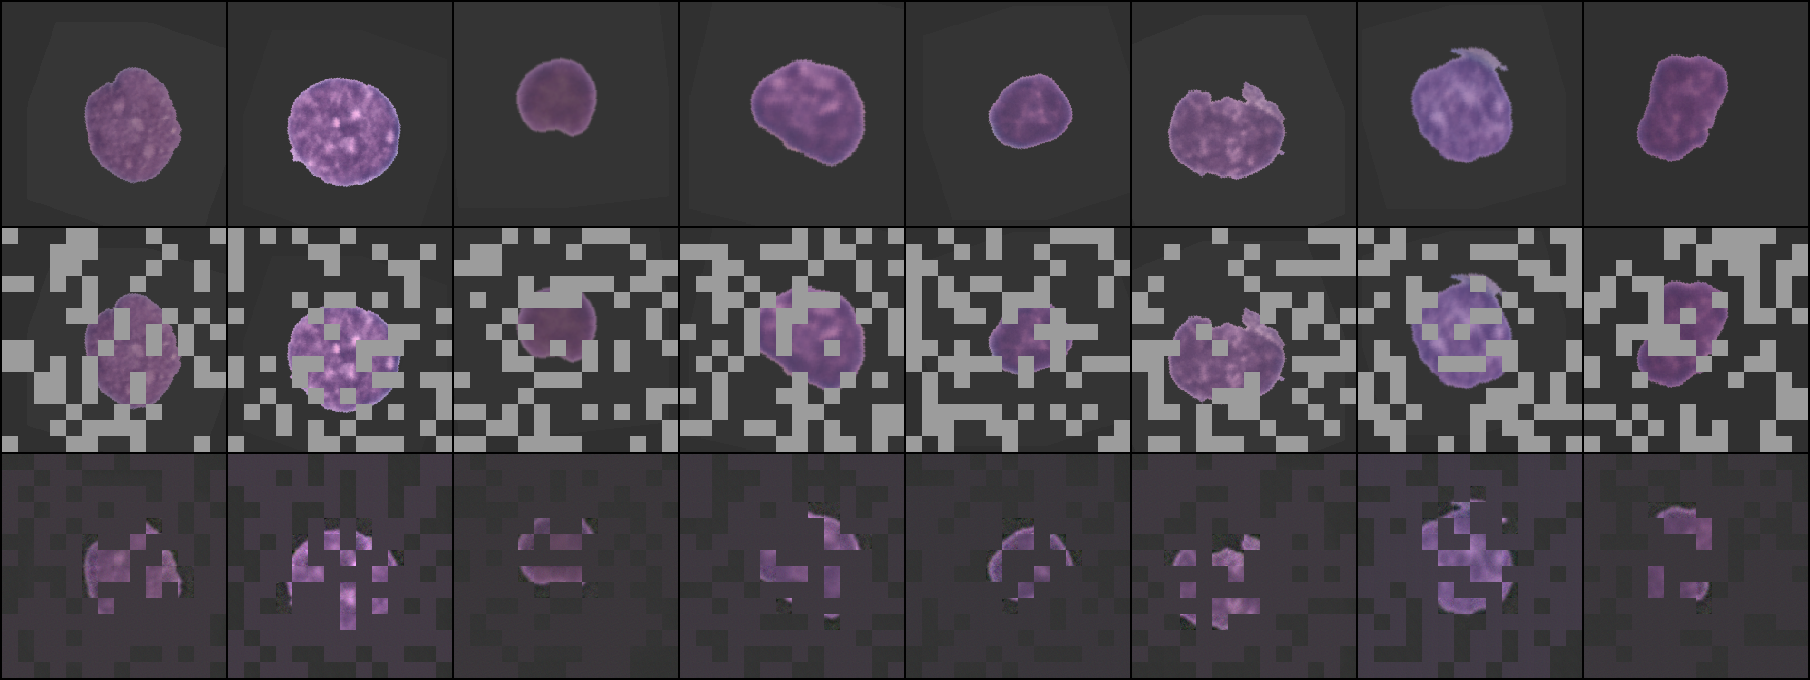

📉 Epoch 011 | Avg Loss = 0.030243 | LR = 0.00014995


📉 Epoch 012 | Avg Loss = 0.030035 | LR = 0.00014982
🏆 New Best Model Saved (Loss 0.030035) → /content/drive/MyDrive/Leukemia Project/checkpoints/mae_best_model.pth


📉 Epoch 013 | Avg Loss = 0.029705 | LR = 0.00014959
🏆 New Best Model Saved (Loss 0.029705) → /content/drive/MyDrive/Leukemia Project/checkpoints/mae_best_model.pth


📉 Epoch 014 | Avg Loss = 0.030354 | LR = 0.00014927


📉 Epoch 015 | Avg Loss = 0.029972 | LR = 0.00014886


📉 Epoch 016 | Avg Loss = 0.029903 | LR = 0.00014836


📉 Epoch 017 | Avg Loss = 0.029829 | LR = 0.00014777


📉 Epoch 018 | Avg Loss = 0.029426 | LR = 0.00014709
🏆 New Best Model Saved (Loss 0.029426) → /content/drive/MyDrive/Leukemia Project/checkpoints/mae_best_model.pth


📉 Epoch 019 | Avg Loss = 0.029503 | LR = 0.00014633


📉 Epoch 020 | Avg Loss = 0.029655 | LR = 0.00014548
🖼️ Saved reconstruction grid: /content/drive/MyDrive/Leukemia Project/visuals/reconstruction_epoch_20.png


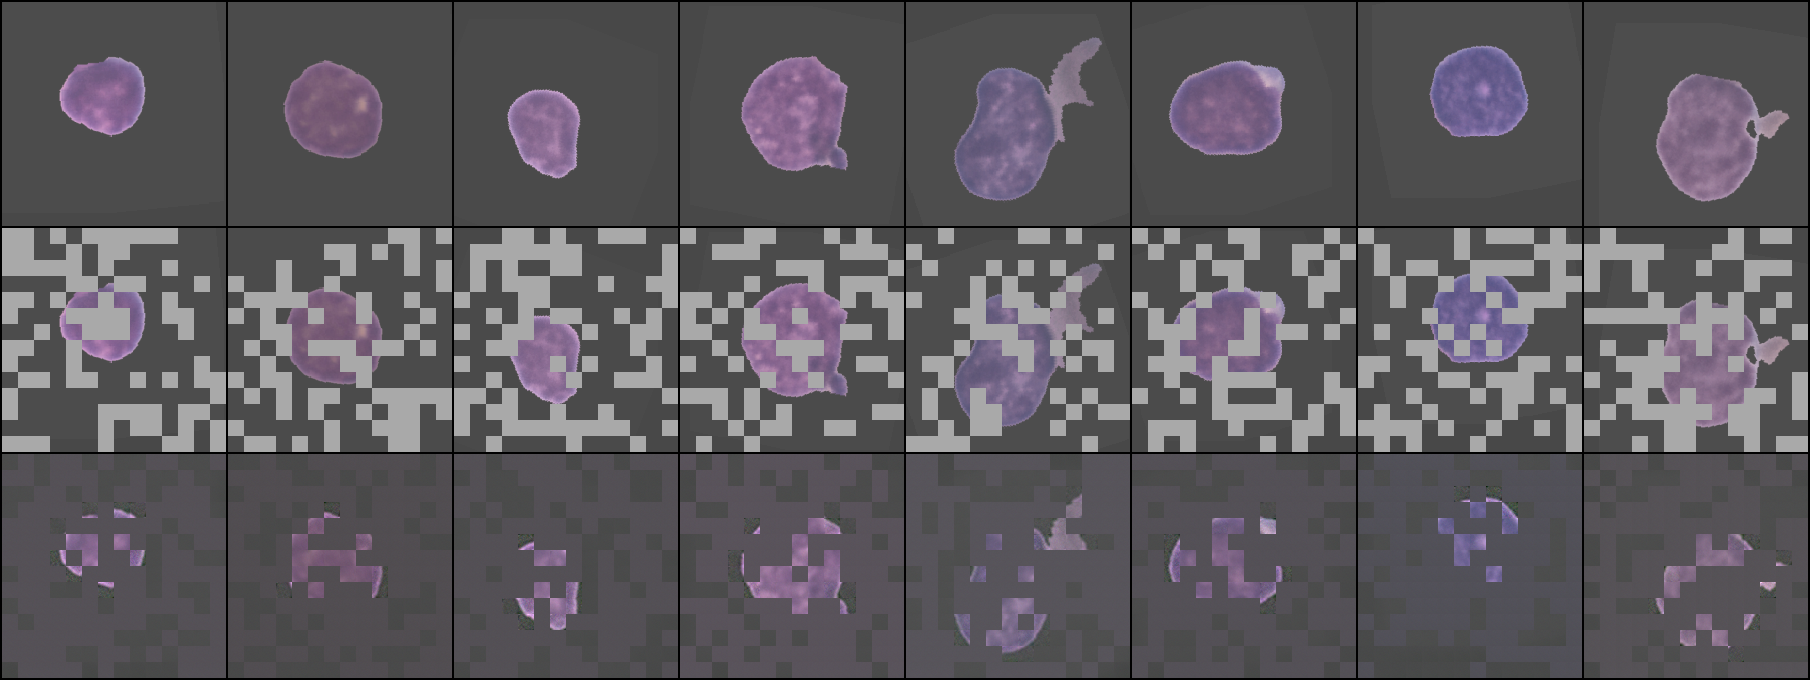

📉 Epoch 021 | Avg Loss = 0.029656 | LR = 0.00014454


📉 Epoch 022 | Avg Loss = 0.029811 | LR = 0.00014352


📉 Epoch 023 | Avg Loss = 0.029749 | LR = 0.00014241


📉 Epoch 024 | Avg Loss = 0.029395 | LR = 0.00014122
🏆 New Best Model Saved (Loss 0.029395) → /content/drive/MyDrive/Leukemia Project/checkpoints/mae_best_model.pth


📉 Epoch 025 | Avg Loss = 0.029220 | LR = 0.00013995
🏆 New Best Model Saved (Loss 0.029220) → /content/drive/MyDrive/Leukemia Project/checkpoints/mae_best_model.pth


📉 Epoch 026 | Avg Loss = 0.029481 | LR = 0.00013860


📉 Epoch 027 | Avg Loss = 0.029511 | LR = 0.00013718


📉 Epoch 028 | Avg Loss = 0.029433 | LR = 0.00013568


📉 Epoch 029 | Avg Loss = 0.029607 | LR = 0.00013410


📉 Epoch 030 | Avg Loss = 0.029483 | LR = 0.00013245
🖼️ Saved reconstruction grid: /content/drive/MyDrive/Leukemia Project/visuals/reconstruction_epoch_30.png


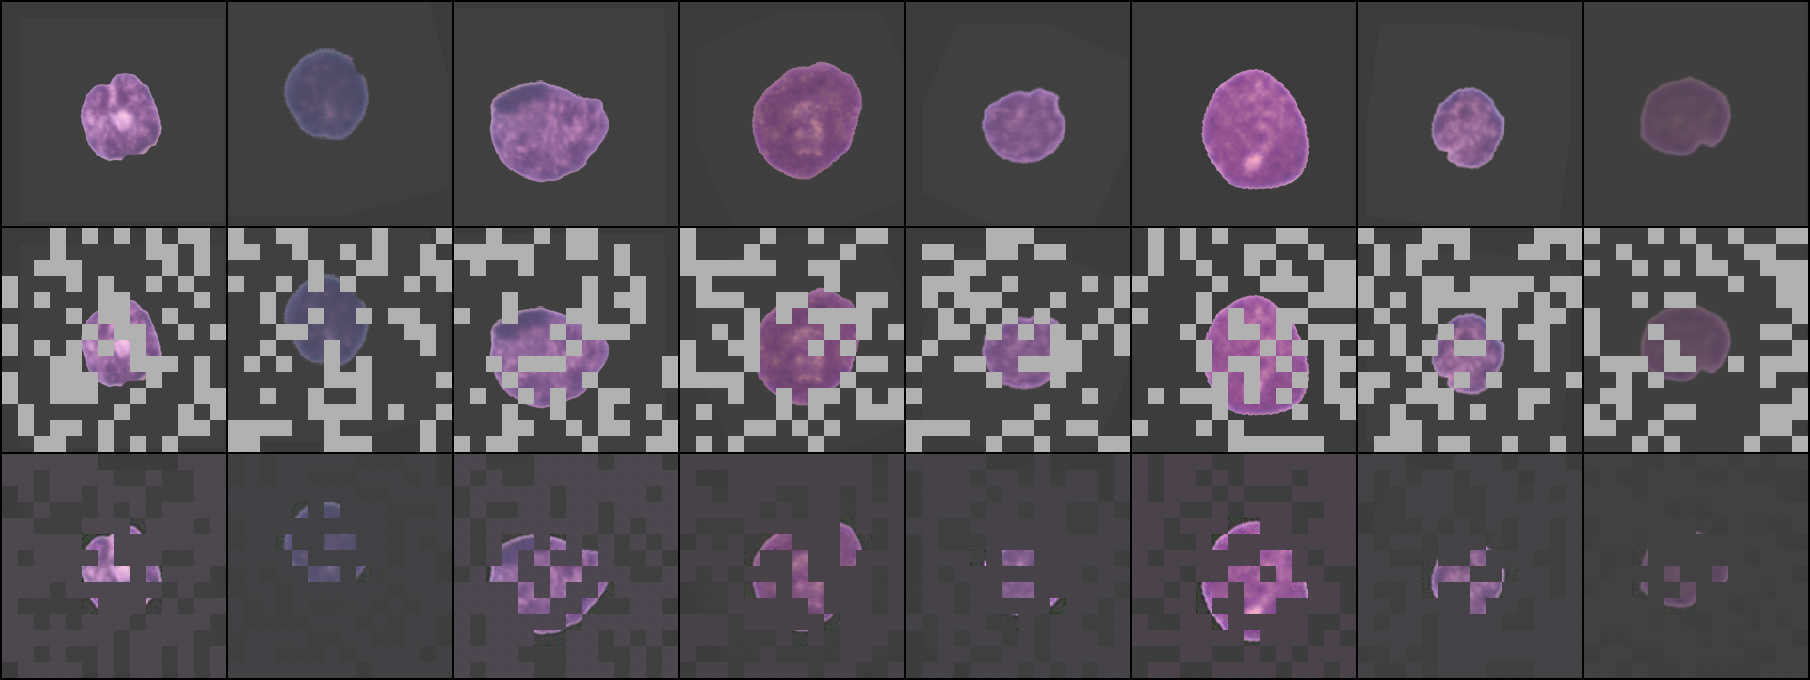

📉 Epoch 031 | Avg Loss = 0.029483 | LR = 0.00013074
🛑 Early-Stop Backup Saved: /content/drive/MyDrive/Leukemia Project/checkpoints/mae_earlystop_epoch_31.pth


📉 Epoch 032 | Avg Loss = 0.029489 | LR = 0.00012895


📉 Epoch 033 | Avg Loss = 0.029189 | LR = 0.00012710
🏆 New Best Model Saved (Loss 0.029189) → /content/drive/MyDrive/Leukemia Project/checkpoints/mae_best_model.pth


📉 Epoch 034 | Avg Loss = 0.029461 | LR = 0.00012518


📉 Epoch 035 | Avg Loss = 0.029454 | LR = 0.00012321


📉 Epoch 036 | Avg Loss = 0.029051 | LR = 0.00012117
🏆 New Best Model Saved (Loss 0.029051) → /content/drive/MyDrive/Leukemia Project/checkpoints/mae_best_model.pth


📉 Epoch 037 | Avg Loss = 0.029311 | LR = 0.00011908


📉 Epoch 038 | Avg Loss = 0.029133 | LR = 0.00011694


📉 Epoch 039 | Avg Loss = 0.029091 | LR = 0.00011474


📉 Epoch 040 | Avg Loss = 0.028876 | LR = 0.00011250
🏆 New Best Model Saved (Loss 0.028876) → /content/drive/MyDrive/Leukemia Project/checkpoints/mae_best_model.pth
🖼️ Saved reconstruction grid: /content/drive/MyDrive/Leukemia Project/visuals/reconstruction_epoch_40.png


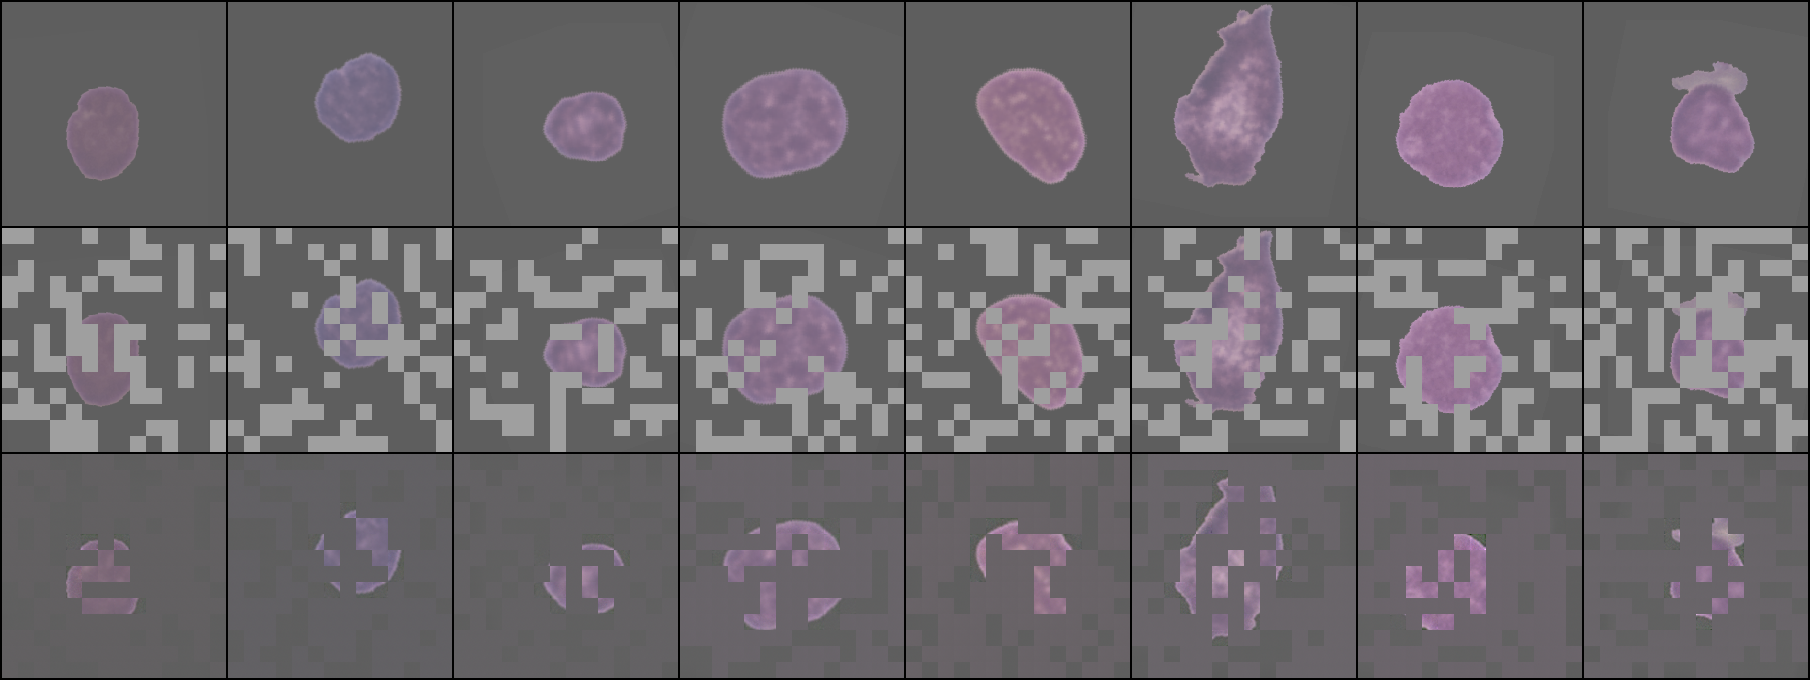

📉 Epoch 041 | Avg Loss = 0.029079 | LR = 0.00011021


📉 Epoch 042 | Avg Loss = 0.029241 | LR = 0.00010788


📉 Epoch 043 | Avg Loss = 0.029420 | LR = 0.00010551


📉 Epoch 044 | Avg Loss = 0.029442 | LR = 0.00010310


📉 Epoch 045 | Avg Loss = 0.029102 | LR = 0.00010065


📉 Epoch 046 | Avg Loss = 0.029564 | LR = 0.00009818
🛑 Early-Stop Backup Saved: /content/drive/MyDrive/Leukemia Project/checkpoints/mae_earlystop_epoch_46.pth


📉 Epoch 047 | Avg Loss = 0.028848 | LR = 0.00009567
🏆 New Best Model Saved (Loss 0.028848) → /content/drive/MyDrive/Leukemia Project/checkpoints/mae_best_model.pth


📉 Epoch 048 | Avg Loss = 0.029161 | LR = 0.00009314


📉 Epoch 049 | Avg Loss = 0.029006 | LR = 0.00009059


📉 Epoch 050 | Avg Loss = 0.029338 | LR = 0.00008802
🖼️ Saved reconstruction grid: /content/drive/MyDrive/Leukemia Project/visuals/reconstruction_epoch_50.png


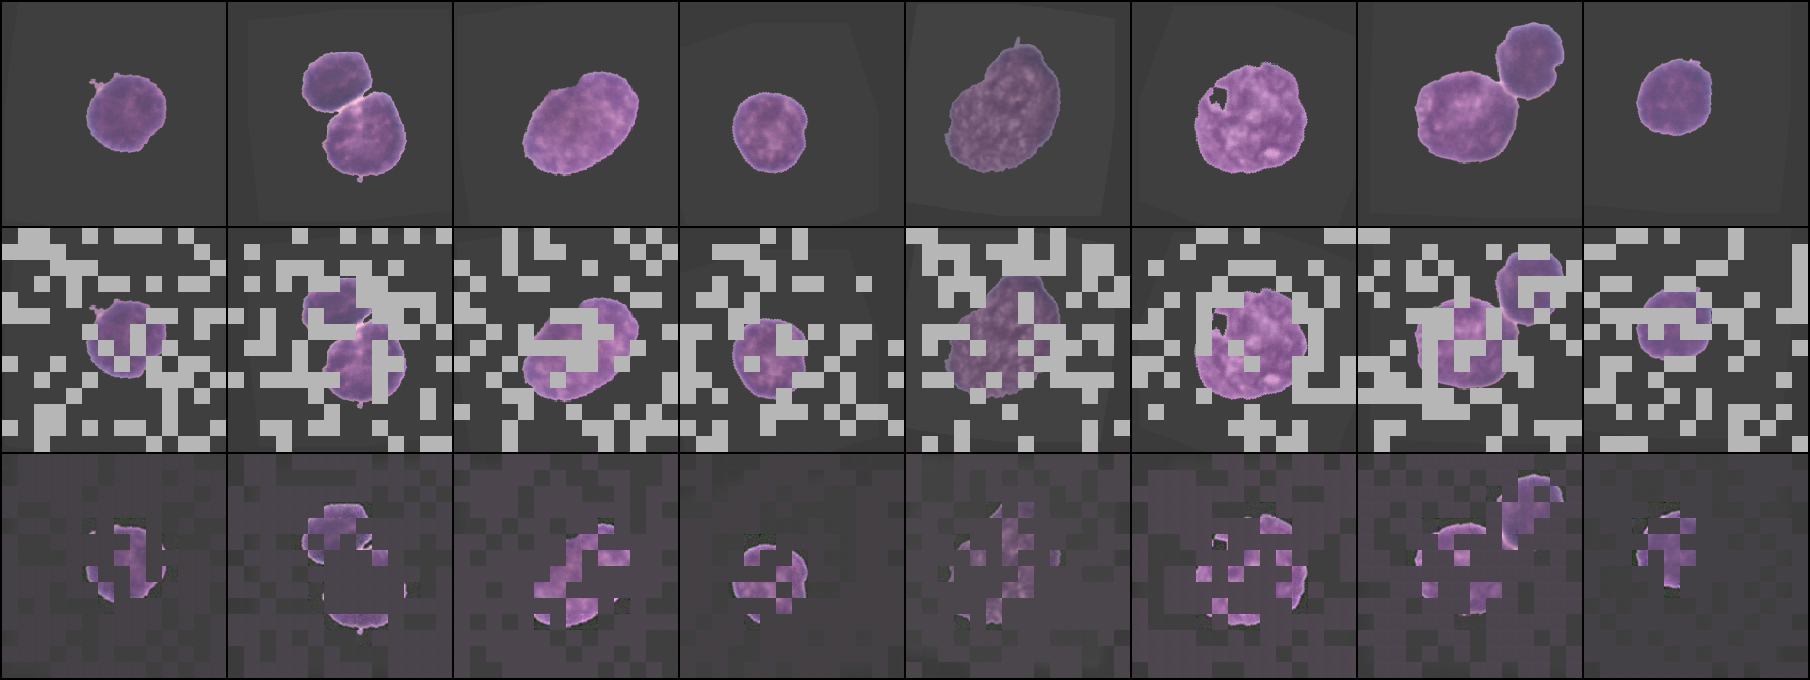

📉 Epoch 051 | Avg Loss = 0.029166 | LR = 0.00008544


📉 Epoch 052 | Avg Loss = 0.029150 | LR = 0.00008284


📉 Epoch 053 | Avg Loss = 0.028964 | LR = 0.00008023
🛑 Early-Stop Backup Saved: /content/drive/MyDrive/Leukemia Project/checkpoints/mae_earlystop_epoch_53.pth


📉 Epoch 054 | Avg Loss = 0.028945 | LR = 0.00007762


📉 Epoch 055 | Avg Loss = 0.029036 | LR = 0.00007500


📉 Epoch 056 | Avg Loss = 0.029232 | LR = 0.00007238


📉 Epoch 057 | Avg Loss = 0.029020 | LR = 0.00006977


📉 Epoch 058 | Avg Loss = 0.029198 | LR = 0.00006716


📉 Epoch 059 | Avg Loss = 0.028672 | LR = 0.00006456
🏆 New Best Model Saved (Loss 0.028672) → /content/drive/MyDrive/Leukemia Project/checkpoints/mae_best_model.pth


📉 Epoch 060 | Avg Loss = 0.028882 | LR = 0.00006198
🖼️ Saved reconstruction grid: /content/drive/MyDrive/Leukemia Project/visuals/reconstruction_epoch_60.png


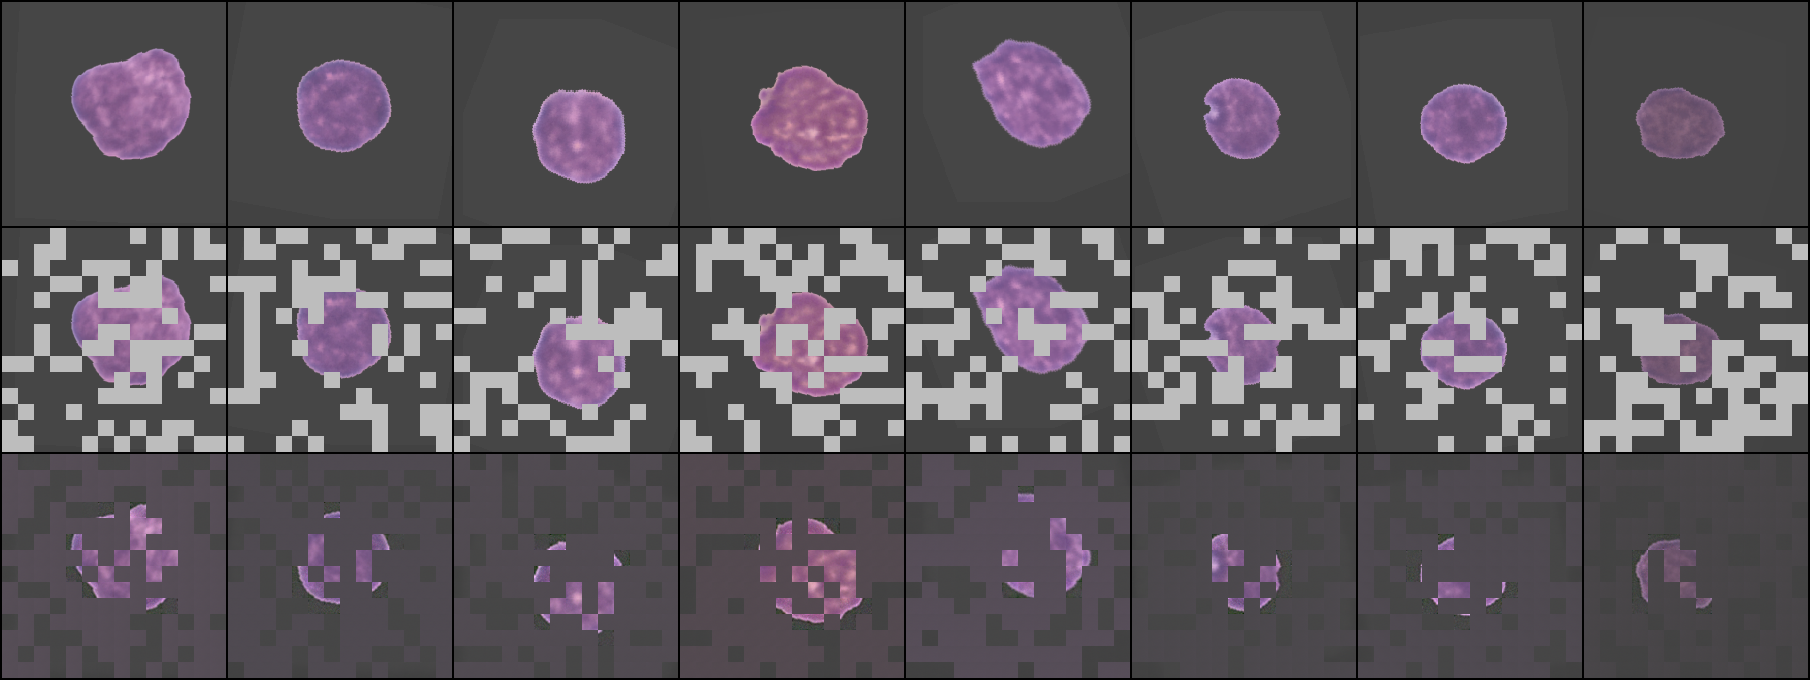

📉 Epoch 061 | Avg Loss = 0.028912 | LR = 0.00005941


📉 Epoch 062 | Avg Loss = 0.029015 | LR = 0.00005686


📉 Epoch 063 | Avg Loss = 0.029097 | LR = 0.00005433


📉 Epoch 064 | Avg Loss = 0.029207 | LR = 0.00005182


📉 Epoch 065 | Avg Loss = 0.029131 | LR = 0.00004935
🛑 Early-Stop Backup Saved: /content/drive/MyDrive/Leukemia Project/checkpoints/mae_earlystop_epoch_65.pth


📉 Epoch 066 | Avg Loss = 0.029198 | LR = 0.00004690


📉 Epoch 067 | Avg Loss = 0.028905 | LR = 0.00004449


📉 Epoch 068 | Avg Loss = 0.028894 | LR = 0.00004212


📉 Epoch 069 | Avg Loss = 0.029304 | LR = 0.00003979


📉 Epoch 070 | Avg Loss = 0.029132 | LR = 0.00003750
🖼️ Saved reconstruction grid: /content/drive/MyDrive/Leukemia Project/visuals/reconstruction_epoch_70.png


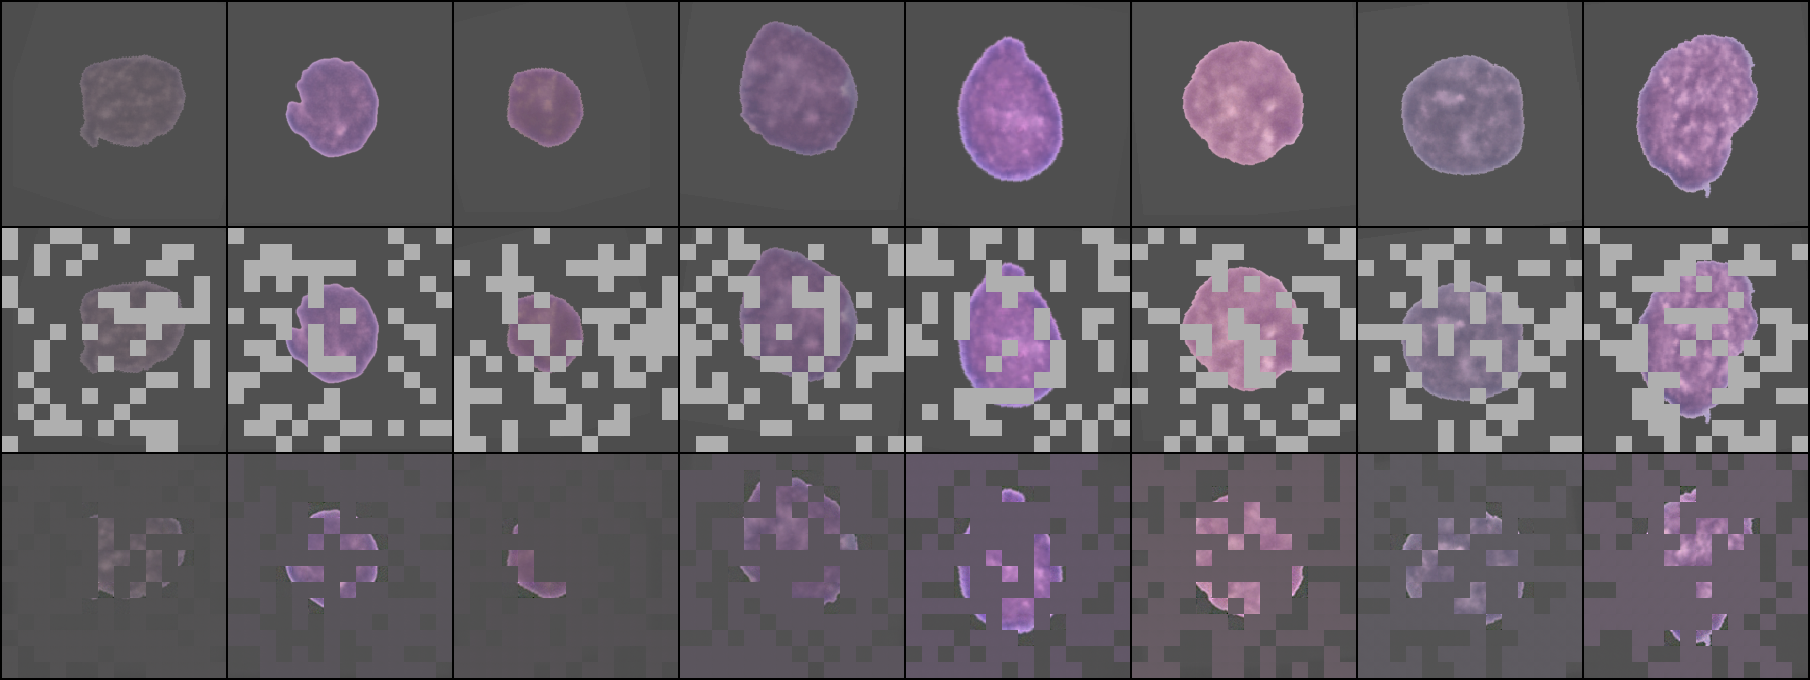

📉 Epoch 071 | Avg Loss = 0.029304 | LR = 0.00003526
🛑 Early-Stop Backup Saved: /content/drive/MyDrive/Leukemia Project/checkpoints/mae_earlystop_epoch_71.pth


📉 Epoch 072 | Avg Loss = 0.029129 | LR = 0.00003306


📉 Epoch 073 | Avg Loss = 0.028914 | LR = 0.00003092


📉 Epoch 074 | Avg Loss = 0.029117 | LR = 0.00002883


📉 Epoch 075 | Avg Loss = 0.028586 | LR = 0.00002679
🏆 New Best Model Saved (Loss 0.028586) → /content/drive/MyDrive/Leukemia Project/checkpoints/mae_best_model.pth


📉 Epoch 076 | Avg Loss = 0.029197 | LR = 0.00002482


📉 Epoch 077 | Avg Loss = 0.028787 | LR = 0.00002290


📉 Epoch 078 | Avg Loss = 0.028936 | LR = 0.00002105


📉 Epoch 079 | Avg Loss = 0.028708 | LR = 0.00001926


📉 Epoch 080 | Avg Loss = 0.028889 | LR = 0.00001755
🖼️ Saved reconstruction grid: /content/drive/MyDrive/Leukemia Project/visuals/reconstruction_epoch_80.png


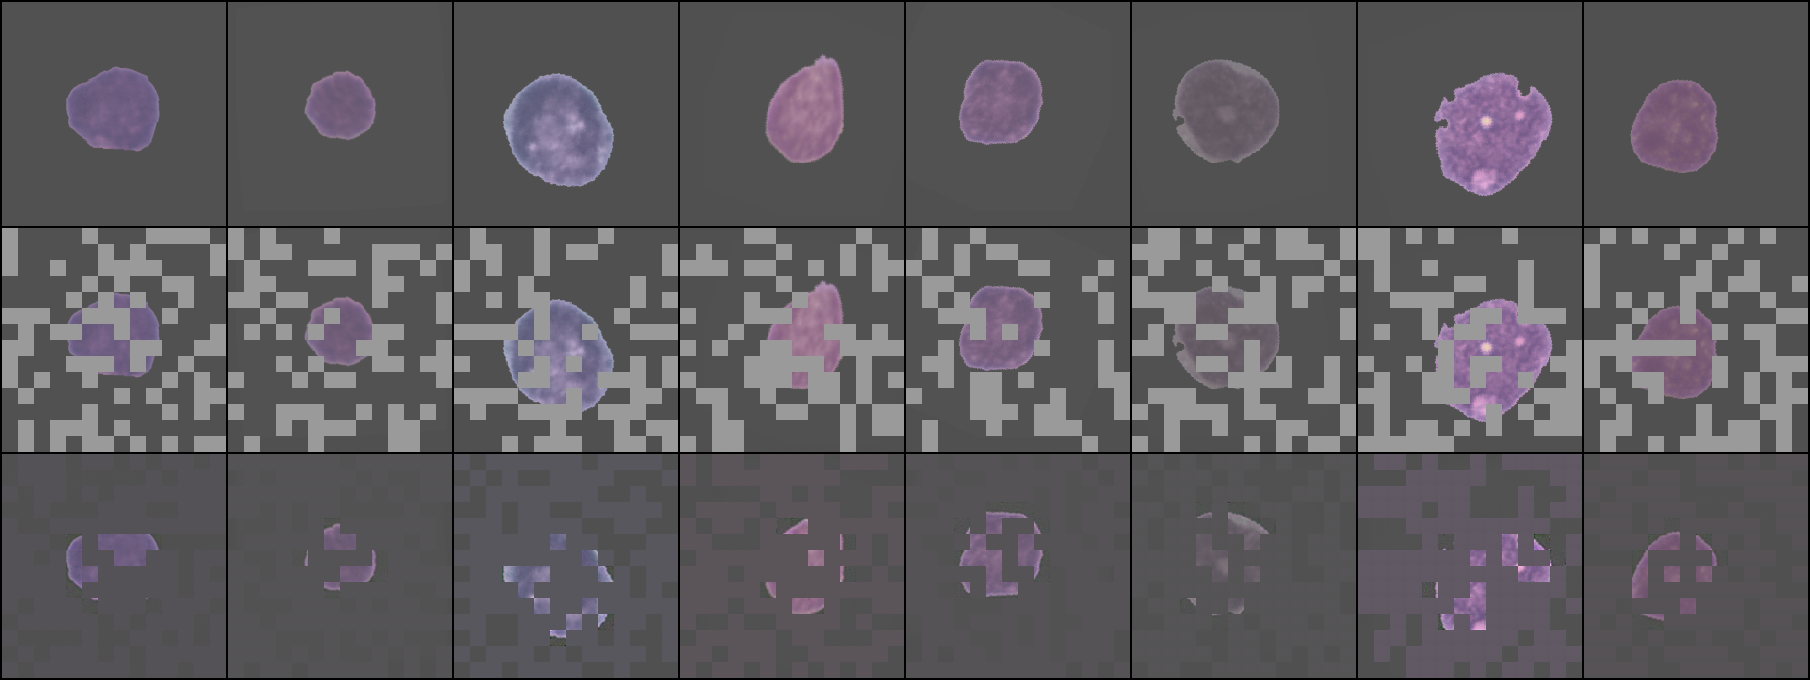

📉 Epoch 081 | Avg Loss = 0.028690 | LR = 0.00001590
🛑 Early-Stop Backup Saved: /content/drive/MyDrive/Leukemia Project/checkpoints/mae_earlystop_epoch_81.pth


📉 Epoch 082 | Avg Loss = 0.028785 | LR = 0.00001432


📉 Epoch 083 | Avg Loss = 0.028808 | LR = 0.00001282


📉 Epoch 084 | Avg Loss = 0.029227 | LR = 0.00001140


📉 Epoch 085 | Avg Loss = 0.028742 | LR = 0.00001005


📉 Epoch 086 | Avg Loss = 0.029494 | LR = 0.00000878


📉 Epoch 087 | Avg Loss = 0.028700 | LR = 0.00000759
🛑 Early-Stop Backup Saved: /content/drive/MyDrive/Leukemia Project/checkpoints/mae_earlystop_epoch_87.pth


📉 Epoch 088 | Avg Loss = 0.028734 | LR = 0.00000648


📉 Epoch 089 | Avg Loss = 0.028881 | LR = 0.00000546


📉 Epoch 090 | Avg Loss = 0.028745 | LR = 0.00000452
🖼️ Saved reconstruction grid: /content/drive/MyDrive/Leukemia Project/visuals/reconstruction_epoch_90.png


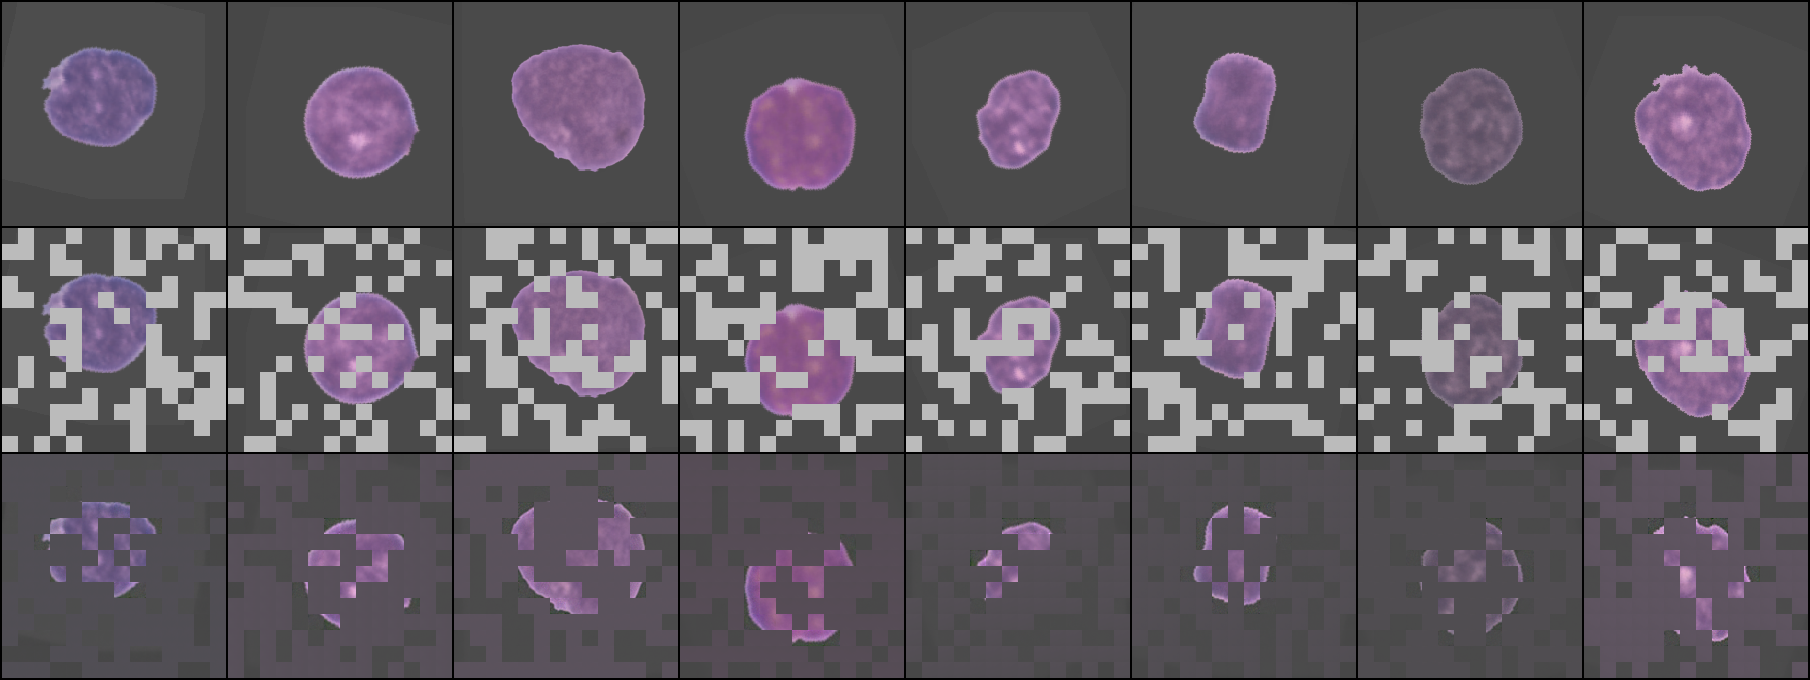

📉 Epoch 091 | Avg Loss = 0.028885 | LR = 0.00000367


📉 Epoch 092 | Avg Loss = 0.028726 | LR = 0.00000291


📉 Epoch 093 | Avg Loss = 0.028749 | LR = 0.00000223
🛑 Early-Stop Backup Saved: /content/drive/MyDrive/Leukemia Project/checkpoints/mae_earlystop_epoch_93.pth


📉 Epoch 094 | Avg Loss = 0.029163 | LR = 0.00000164


📉 Epoch 095 | Avg Loss = 0.028860 | LR = 0.00000114


📉 Epoch 096 | Avg Loss = 0.028812 | LR = 0.00000073


📉 Epoch 097 | Avg Loss = 0.028841 | LR = 0.00000041


📉 Epoch 098 | Avg Loss = 0.028708 | LR = 0.00000018


📉 Epoch 099 | Avg Loss = 0.029127 | LR = 0.00000005
🛑 Early-Stop Backup Saved: /content/drive/MyDrive/Leukemia Project/checkpoints/mae_earlystop_epoch_99.pth


📉 Epoch 100 | Avg Loss = 0.029069 | LR = 0.00000000
🖼️ Saved reconstruction grid: /content/drive/MyDrive/Leukemia Project/visuals/reconstruction_epoch_100.png


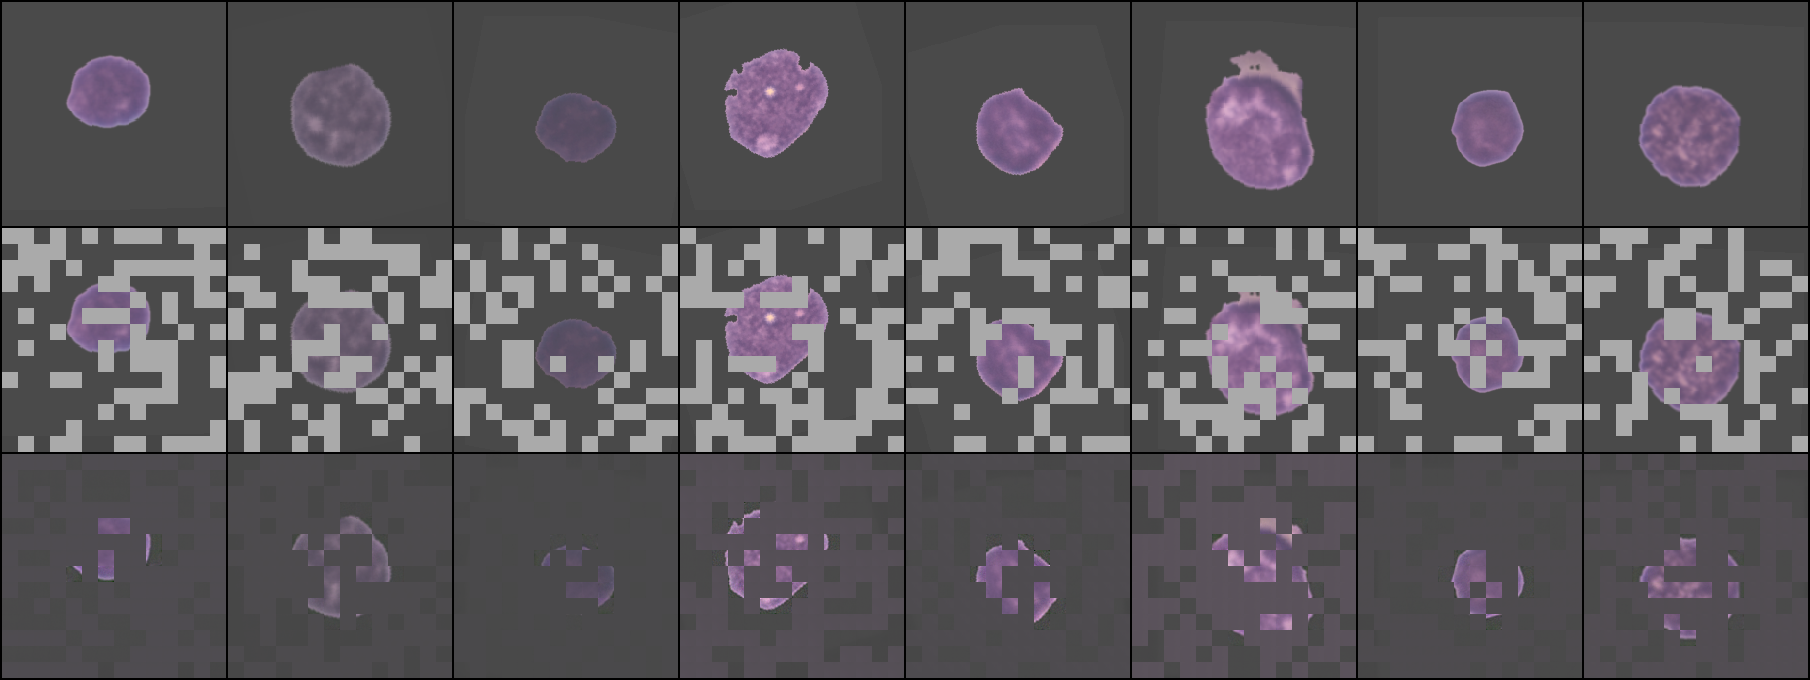


✅ MAE Pretraining Completed Successfully!
📊 Final Avg Loss: 0.029069
🏁 Best Model Saved at: /content/drive/MyDrive/Leukemia Project/checkpoints/mae_best_model.pth (Loss: 0.028586)


In [ ]:
# =========================
# 🔹 Cell 7 — MAE Pretraining Loop (Enhanced, Stable & Journal-Ready)
# =========================

from tqdm import tqdm
import torch, csv, os
import torchvision.utils as vutils
from einops import rearrange
from torch.amp import autocast, GradScaler
from IPython.display import Image as IPyImage, display

# ============================================================
# 🧮 Frequency-Aware MAE Loss (cuFFT-Safe + Stable AMP)
# ============================================================
import torch.nn as nn

class FreqAwareMAELoss(nn.Module):
    def __init__(self, alpha=0.8):
        super().__init__()
        self.alpha = alpha
        self.mse = nn.MSELoss()
        self.l1 = nn.L1Loss()

    def forward(self, pred, target):
        # Spatial MSE
        mse_loss = self.mse(pred, target)
        # Frequency loss safely in float32 (avoids cuFFT half precision error)
        fft_pred = torch.fft.rfft2(pred.float(), norm='ortho').abs()
        fft_targ = torch.fft.rfft2(target.float(), norm='ortho').abs()
        fft_loss = self.l1(fft_pred, fft_targ)
        return self.alpha * mse_loss + (1 - self.alpha) * fft_loss

# Initialize loss
criterion = FreqAwareMAELoss(alpha=0.8)

# ============================================================
# 📦 Helper Functions: patchify / unpatchify
# ============================================================
def patchify(imgs, patch_size=16):
    p = patch_size
    assert imgs.shape[2] == imgs.shape[3] and imgs.shape[2] % p == 0
    h = w = imgs.shape[2] // p
    return rearrange(imgs, 'N C (h p1) (w p2) -> N (h w) (p1 p2 C)', p1=p, p2=p)

def unpatchify(x, patch_size=16):
    p = patch_size
    h = w = int(x.shape[1] ** 0.5)
    assert h * w == x.shape[1]
    return rearrange(x, 'N (h w) (p1 p2 C) -> N C (h p1) (w p2)', h=h, w=w, p1=p, p2=p)

# ============================================================
# 🗂️ Output Directories
# ============================================================
ckpt_dir = f"{ROOT_DIR}/checkpoints"
log_dir  = f"{ROOT_DIR}/logs"
vis_dir  = f"{ROOT_DIR}/visuals"
os.makedirs(ckpt_dir, exist_ok=True)
os.makedirs(log_dir, exist_ok=True)
os.makedirs(vis_dir, exist_ok=True)

# ============================================================
# 🔧 Initialize Training Utilities
# ============================================================
train_losses = []
best_loss = float('inf')
patience_counter = 0
early_stop_patience = 6
best_ckpt_path = os.path.join(ckpt_dir, "mae_best_model.pth")
log_csv = os.path.join(log_dir, "train_loss.csv")

with open(log_csv, "w", newline='') as f:
    writer = csv.writer(f)
    writer.writerow(["Epoch", "TrainLoss", "LR", "EMA_Decay"])

print(f"🚀 Starting MAE Pretraining for {num_epochs} epochs...\n")

# ============================================================
# 🎯 Training Loop
# ============================================================
for epoch in range(num_epochs):
    torch.cuda.empty_cache()
    mae_model.train()
    running_loss = 0.0

    progress = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}]", leave=False)

    for imgs, _ in progress:
        imgs = imgs.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        # --- Mixed precision context ---
        with autocast(device_type="cuda"):
            latent, ids_restore = mae_model.forward_encoder(imgs)
            pred = mae_model.forward_decoder(latent, ids_restore)
            target = patchify(imgs, patch_size=mae_model.patch_embed.patch_size)
            loss = criterion(pred, target)

        # --- Backpropagation ---
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(mae_model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        # --- EMA update ---
        ema.update(mae_model)

        running_loss += loss.item() * imgs.size(0)
        progress.set_postfix({"loss": f"{loss.item():.5f}"})

    scheduler.step()
    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)
    lr_now = optimizer.param_groups[0]["lr"]

    print(f"📉 Epoch {epoch+1:03d} | Avg Loss = {epoch_loss:.6f} | LR = {lr_now:.8f}")

    # --- Log to CSV ---
    with open(log_csv, "a", newline='') as f:
        writer = csv.writer(f)
        writer.writerow([epoch + 1, epoch_loss, lr_now, ema.decay])

    # --- Save best model ---
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(mae_model.state_dict(), best_ckpt_path)
        print(f"🏆 New Best Model Saved (Loss {best_loss:.6f}) → {best_ckpt_path}")
        patience_counter = 0
    else:
        patience_counter += 1

    # --- Early stop safeguard ---
    if patience_counter >= early_stop_patience:
        backup_path = os.path.join(ckpt_dir, f"mae_earlystop_epoch_{epoch+1}.pth")
        torch.save(mae_model.state_dict(), backup_path)
        print(f"🛑 Early-Stop Backup Saved: {backup_path}")
        patience_counter = 0

    # --- Visualization every 10 epochs ---
    if (epoch + 1) % 10 == 0:
        mae_model.eval()
        with torch.no_grad():
            imgs_vis = imgs[:8]
            latent, ids_restore = mae_model.forward_encoder(imgs_vis)
            pred = mae_model.forward_decoder(latent, ids_restore)
            recon = unpatchify(pred, patch_size=mae_model.patch_embed.patch_size)

            p = mae_model.patch_embed.patch_size
            h = w = mae_model.patch_embed.grid_size
            mask = torch.rand(imgs_vis.size(0), h*w, device=device) > mae_model.mask_ratio
            mask = mask.unsqueeze(-1).repeat(1, 1, p**2 * 3)
            mask = unpatchify(mask, patch_size=p)
            imgs_masked = imgs_vis * (~mask.bool())
            recon_grid = torch.cat([imgs_vis, imgs_masked, recon], dim=0)

            grid_path = os.path.join(vis_dir, f"reconstruction_epoch_{epoch+1}.png")
            vutils.save_image(recon_grid, grid_path, nrow=imgs_vis.size(0), normalize=True)
            print(f"🖼️ Saved reconstruction grid: {grid_path}")
            display(IPyImage(filename=grid_path))

print("\n✅ MAE Pretraining Completed Successfully!")
print(f"📊 Final Avg Loss: {train_losses[-1]:.6f}")
print(f"🏁 Best Model Saved at: {best_ckpt_path} (Loss: {best_loss:.6f})")


In [ ]:
# ============================================================
# 🧩 Cell 7.1 — Quick Resume Setup (Load Everything Without Rerunning Cells 1–7)
# ============================================================
# Restores MAE model, optimizer, scheduler, EMA, AMP, and loss function.

!pip install -q kagglehub

import kagglehub, os
path = kagglehub.dataset_download("andrewmvd/leukemia-classification")
print("✅ Dataset downloaded to:", path)


import torch, os, random
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import numpy as np
from pathlib import Path
import pandas as pd
import timm
from einops import rearrange
from torch.amp import GradScaler

# --- Step 1: Reconnect Drive and Directories ---
ROOT_DIR = '/content/drive/MyDrive/Leukemia Project'
CHECKPOINT_DIR = os.path.join(ROOT_DIR, 'checkpoints')
VISUALS_DIR = os.path.join(ROOT_DIR, 'visuals')
LOG_DIR = os.path.join(ROOT_DIR, 'logs')

if not os.path.exists(ROOT_DIR):
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    print("✅ Google Drive remounted successfully.")

# --- Step 2: Device & Reproducibility ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.benchmark = True

# --- Step 3: Minimal Dataset (Validation/Visualization only) ---
val_dir = Path("/root/.cache/kagglehub/datasets/andrewmvd/leukemia-classification/versions/2/C-NMC_Leukemia/validation_data")
val_img_dir = val_dir / "C-NMC_test_prelim_phase_data"
csv_path = val_dir / "C-NMC_test_prelim_phase_data_labels.csv"

labels_df = pd.read_csv(csv_path)[["Patient_ID", "labels"]]
labels_df.columns = ["Image_Name", "LabelEncoded"]

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

class SimpleDataset(Dataset):
    def __init__(self, img_dir, labels_df, transform=None):
        self.img_dir = Path(img_dir)
        self.labels_df = labels_df
        self.transform = transform
    def __len__(self): return len(self.labels_df)
    def __getitem__(self, idx):
        row = self.labels_df.iloc[idx]
        img_path = self.img_dir / row["Image_Name"]
        image = Image.open(img_path).convert("RGB")
        label = int(row["LabelEncoded"])
        if self.transform: image = self.transform(image)
        return image, label

dataset = SimpleDataset(val_img_dir, labels_df, transform=test_transform)
test_loader = DataLoader(dataset, batch_size=8, shuffle=True, num_workers=2)
print(f"✅ Validation dataset successfully built with {len(dataset)} images.")

# --- Step 4: MAE Model Definition (must match pretraining) ---
class PatchEmbed(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=768):
        super().__init__()
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.num_patches = (img_size // patch_size) ** 2
    def forward(self, x):
        x = self.proj(x)
        return x.flatten(2).transpose(1, 2)

class MaskedAutoencoderViT(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3,
                 embed_dim=768, depth=12, num_heads=12,
                 decoder_embed_dim=512, decoder_depth=8, decoder_num_heads=8,
                 mlp_ratio=4., mask_ratio=0.75):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, 1 + self.patch_embed.num_patches, embed_dim))
        self.blocks = nn.ModuleList([
            timm.models.vision_transformer.Block(
                dim=embed_dim, num_heads=num_heads, mlp_ratio=mlp_ratio
            ) for _ in range(depth)
        ])
        self.mask_ratio = mask_ratio
        self.decoder_embed = nn.Linear(embed_dim, decoder_embed_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_embed_dim))
        self.decoder_blocks = nn.ModuleList([
            timm.models.vision_transformer.Block(
                dim=decoder_embed_dim, num_heads=decoder_num_heads, mlp_ratio=mlp_ratio
            ) for _ in range(decoder_depth)
        ])
        self.decoder_pred = nn.Linear(decoder_embed_dim, patch_size**2 * in_chans)
        nn.init.normal_(self.pos_embed, std=0.02)
        nn.init.normal_(self.cls_token, std=0.02)
        nn.init.normal_(self.mask_token, std=0.02)

    def random_masking(self, x):
        B, N, D = x.shape
        len_keep = int(N * (1 - self.mask_ratio))
        noise = torch.rand(B, N, device=x.device)
        ids_shuffle = torch.argsort(noise, dim=1)
        ids_restore = torch.argsort(ids_shuffle, dim=1)
        ids_keep = ids_shuffle[:, :len_keep]
        x_masked = torch.gather(x, 1, ids_keep.unsqueeze(-1).repeat(1, 1, D))
        return x_masked, ids_restore

    def forward_encoder(self, x):
        x = self.patch_embed(x)
        x = x + self.pos_embed[:, 1:, :]
        x, ids_restore = self.random_masking(x)
        cls_token = self.cls_token + self.pos_embed[:, :1, :]
        x = torch.cat([cls_token.expand(x.shape[0], -1, -1), x], 1)
        for blk in self.blocks: x = blk(x)
        return x, ids_restore

    def forward_decoder(self, x, ids_restore):
        x = self.decoder_embed(x)
        B, N, D = x.shape
        mask_tokens = self.mask_token.repeat(B, ids_restore.shape[1] + 1 - N, 1)
        x_ = torch.cat([x[:, 1:, :], mask_tokens], 1)
        x_ = torch.gather(x_, 1, ids_restore.unsqueeze(-1).repeat(1, 1, D))
        x_ = torch.cat([x[:, :1, :], x_], 1)
        for blk in self.decoder_blocks: x_ = blk(x_)
        return self.decoder_pred(x_[:, 1:, :])

    def forward(self, imgs):
        latent, ids_restore = self.forward_encoder(imgs)
        pred = self.forward_decoder(latent, ids_restore)
        return ((pred - imgs.flatten(2).transpose(1, 2)) ** 2).mean(), pred

# --- Step 5: Load pretrained checkpoint ---
mae_model = MaskedAutoencoderViT().to(device)
ckpt_path = os.path.join(CHECKPOINT_DIR, "mae_best_model.pth")

if os.path.exists(ckpt_path):
    state_dict = torch.load(ckpt_path, map_location=device)
    mae_model.load_state_dict(state_dict, strict=False)
    print(f"✅ Loaded pretrained MAE weights from: {ckpt_path}")
else:
    print("⚠️ No checkpoint found. Please verify training finished and file exists.")

torch.cuda.empty_cache()

# --- Step 6: Recreate optimizer, scheduler, scaler, EMA ---
optimizer = AdamW(mae_model.parameters(), lr=1.5e-4, betas=(0.9, 0.95), weight_decay=0.05)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-6)
scaler = GradScaler("cuda")

# --- ✅ Step 7: Restore Frequency-Aware Loss (matches Cell 7) ---
class FreqAwareMAELoss(nn.Module):
    def __init__(self, alpha=0.8):
        super().__init__()
        self.alpha = alpha
        self.mse = nn.MSELoss()
        self.l1 = nn.L1Loss()
    def forward(self, pred, target):
        mse_loss = self.mse(pred, target)
        fft_pred = torch.fft.rfft2(pred.float(), norm='ortho').abs()
        fft_targ = torch.fft.rfft2(target.float(), norm='ortho').abs()
        fft_loss = self.l1(fft_pred, fft_targ)
        return self.alpha * mse_loss + (1 - self.alpha) * fft_loss

criterion = FreqAwareMAELoss(alpha=0.8)

# --- Optional EMA restore (reinitialize if missing) ---
try:
    ema = ema  # reuse if already defined
except NameError:
    class EMA:
        def __init__(self, model, decay=0.999):
            self.model_shadow = {n: p.clone().detach() for n, p in model.state_dict().items()}
            self.decay = decay
        def update(self, model):
            for name, param in model.state_dict().items():
                if name in self.model_shadow:
                    self.model_shadow[name].mul_(self.decay).add_(param.detach(), alpha=1 - self.decay)
    ema = EMA(mae_model)

print(f"\n⚙️ Environment fully restored — ready to continue MAE pretraining or move to fine-tuning.")
print(f"🧠 Device: {device} | Params: {sum(p.numel() for p in mae_model.parameters())/1e6:.2f} M")
print(f"📁 Checkpoint: {os.path.basename(ckpt_path)} | Dataset size: {len(dataset)} | LR: {optimizer.param_groups[0]['lr']}")


100%|██████████| 867M/867M [00:09<00:00, 100MB/s] 

Extracting files...


✅ Dataset downloaded to: /root/.cache/kagglehub/datasets/andrewmvd/leukemia-classification/versions/2
Mounted at /content/drive
✅ Google Drive remounted successfully.
✅ Validation dataset successfully built with 1867 images.
✅ Loaded pretrained MAE weights from: /content/drive/MyDrive/Leukemia Project/checkpoints/mae_best_model.pth

⚙️ Environment fully restored — ready to continue MAE pretraining or move to fine-tuning.
🧠 Device: cuda | Params: 111.76 M
📁 Checkpoint: mae_best_model.pth | Dataset size: 1867 | LR: 0.00015


In [ ]:
# ============================================================
# 🩸 CELL 8 — Supervised Fine-Tuning of MAE-Pretrained ViT (Final Optimized)
# ============================================================

import torch, os, numpy as np, pandas as pd
from torch import nn, optim
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.nn.utils import clip_grad_norm_
from transformers import ViTForImageClassification
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# ------------------------------------------------------------
# ✅ Load MAE-Pretrained Encoder
# ------------------------------------------------------------
mae_checkpoint = "/content/drive/MyDrive/Leukemia Project/checkpoints/mae_best_model.pth"
save_path = "/content/drive/MyDrive/Leukemia Project/checkpoints/vit_finetuned_mae_best.pth"
os.makedirs(os.path.dirname(save_path), exist_ok=True)

model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=2,
    ignore_mismatched_sizes=True
).to(device)

# Robust key-mapping for MAE→ViT
mae_state = torch.load(mae_checkpoint, map_location=device)
filtered_state = {}
for k, v in mae_state.items():
    if k.startswith("encoder.blocks.") or k.startswith("blocks."):
        filtered_state[f"vit.encoder.layer.{k.split('.',2)[-1]}"] = v
    elif any(k.startswith(x) for x in ["patch_embed", "cls_token", "pos_embed"]):
        filtered_state[f"vit.{k}"] = v

missing, unexpected = model.load_state_dict(filtered_state, strict=False)
print(f"✅ Loaded MAE encoder weights → Missing: {len(missing)} | Unexpected: {len(unexpected)}")

# Reset classifier head for 2-class leukemia classification
nn.init.xavier_uniform_(model.classifier.weight)
nn.init.zeros_(model.classifier.bias)

# ------------------------------------------------------------
# ✅ Loss, Optimizer, Scheduler
# ------------------------------------------------------------
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = optim.AdamW(model.parameters(), lr=3e-5, weight_decay=0.05)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2, eta_min=1e-6)

num_epochs, warmup_epochs, freeze_epochs = 25, 3, 5
best_val_f1 = 0.0
log_path = "/content/drive/MyDrive/Leukemia Project/logs/vit_finetuning_log.csv"
os.makedirs(os.path.dirname(log_path), exist_ok=True)
pd.DataFrame(columns=["Epoch","TrainLoss","ValLoss","ValAcc","ValF1"]).to_csv(log_path, index=False)

# ------------------------------------------------------------
# ✅ Exponential Moving Average (EMA)
# ------------------------------------------------------------
ema_model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=2,
    ignore_mismatched_sizes=True
).to(device)
ema_model.load_state_dict(model.state_dict())
ema_decay = 0.995

# ------------------------------------------------------------
# ✅ Training Loop
# ------------------------------------------------------------
print(f"\n🚀 Starting Supervised Fine-Tuning for {num_epochs} epochs...\n")
scaler = torch.cuda.amp.GradScaler(enabled=(device=="cuda"))

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    # --- Gradual unfreezing ---
    for name, p in model.vit.named_parameters():
        p.requires_grad = epoch >= freeze_epochs

    # --- LR warm-up ---
    if epoch < warmup_epochs:
        warm_lr = 1e-5 + (epoch / warmup_epochs) * (3e-5 - 1e-5)
        for g in optimizer.param_groups: g["lr"] = warm_lr

    # --- Training step ---
    for images, labels in tqdm(train_loader, desc=f"Training Epoch {epoch+1:03d}/{num_epochs}"):
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=(device=="cuda")):
            outputs = model(images)
            loss = criterion(outputs.logits, labels)
        scaler.scale(loss).backward()
        clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer); scaler.update()
        train_loss += loss.item() * images.size(0)

        # EMA update
        with torch.no_grad():
            for (n, p), (_, ep) in zip(model.named_parameters(), ema_model.named_parameters()):
                ep.mul_(ema_decay).add_(p.data, alpha=1 - ema_decay)

    avg_train_loss = train_loss / len(train_loader.dataset)

    # --- Validation ---
    ema_model.eval()
    val_loss, preds, targets = 0.0, [], []
    with torch.no_grad(), torch.cuda.amp.autocast(enabled=(device=="cuda")):
        for images, labels in val_loader:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            outputs = ema_model(images)
            loss = criterion(outputs.logits, labels)
            val_loss += loss.item() * images.size(0)
            preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
            targets.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader.dataset)
    val_acc = accuracy_score(targets, preds)
    val_f1 = f1_score(targets, preds)
    scheduler.step(epoch + 1)

    print(f"📉 Epoch {epoch+1:03d}/{num_epochs} | "
          f"Train Loss {avg_train_loss:.5f} | "
          f"Val Loss {avg_val_loss:.5f} | "
          f"Val Acc {val_acc:.4f} | Val F1 {val_f1:.4f}")

    # Log metrics
    pd.DataFrame([[epoch+1, avg_train_loss, avg_val_loss, val_acc, val_f1]],
                 columns=["Epoch","TrainLoss","ValLoss","ValAcc","ValF1"]
                 ).to_csv(log_path, mode="a", header=False, index=False)

    # Confusion Matrix every 5 epochs
    if (epoch + 1) % 5 == 0:
        print(f"🧾 Confusion Matrix @ Epoch {epoch+1}:\n{confusion_matrix(targets, preds)}")

    # Save best
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(ema_model.state_dict(), save_path)
        print(f"🏆 New Best Model Saved (F1 {best_val_f1:.4f}) → {save_path}")

print("\n✅ Fine-tuning complete. Best model stored at:")
print(save_path)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([2]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Loaded MAE encoder weights → Missing: 200 | Unexpected: 17


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([2]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

📉 Epoch 023/25 | Train Loss 0.30412 | Val Loss 0.30032 | Val Acc 0.9006 | Val F1 0.9264


Training Epoch 024/25: 100%|██████████| 117/117 [01:38<00:00,  1.19it/s]


📉 Epoch 024/25 | Train Loss 0.30673 | Val Loss 0.30278 | Val Acc 0.9024 | Val F1 0.9278
🏆 New Best Model Saved (F1 0.9278) → /content/drive/MyDrive/Leukemia Project/checkpoints/vit_finetuned_mae_best.pth


Training Epoch 025/25: 100%|██████████| 117/117 [01:45<00:00,  1.10it/s]


📉 Epoch 025/25 | Train Loss 0.29904 | Val Loss 0.29925 | Val Acc 0.9056 | Val F1 0.9302
🧾 Confusion Matrix @ Epoch 25:
[[ 442   66]
 [  85 1006]]
🏆 New Best Model Saved (F1 0.9302) → /content/drive/MyDrive/Leukemia Project/checkpoints/vit_finetuned_mae_best.pth

✅ Fine-tuning complete. Best model stored at:
/content/drive/MyDrive/Leukemia Project/checkpoints/vit_finetuned_mae_best.pth


In [ ]:
# ============================================================
# 🩸 CELL 8.1 — Resume Fine-Tuned MAE-Pretrained ViT (Enhanced + Safe)
# ============================================================

import torch
from torch import nn, optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from transformers import ViTForImageClassification
import os

# -----------------------------
# ✅ Define paths and device
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
base_dir = "/content/drive/MyDrive/Leukemia Project/checkpoints"
mae_checkpoint = os.path.join(base_dir, "mae_best_model.pth")
finetuned_checkpoint = os.path.join(base_dir, "vit_finetuned_mae_best.pth")

print(f"📁 Checkpoint directory: {base_dir}")
print(f"🧠 Using device: {device}")

# -----------------------------
# ✅ Reload model architecture
# -----------------------------
model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=2,
    ignore_mismatched_sizes=True
).to(device)

# -----------------------------
# ✅ (Optional) Reload MAE encoder weights (filtered & remapped)
# -----------------------------
if os.path.exists(mae_checkpoint):
    mae_state = torch.load(mae_checkpoint, map_location=device)
    filtered_state = {}
    for k, v in mae_state.items():
        if k.startswith("blocks."):
            filtered_state[f"vit.encoder.layer.{k.split('.', 1)[1]}"] = v
        elif any(k.startswith(x) for x in ["patch_embed", "cls_token", "pos_embed"]):
            filtered_state[f"vit.{k}"] = v

    missing, unexpected = model.load_state_dict(filtered_state, strict=False)
    print(f"✅ MAE encoder partially loaded ({len(missing)} missing / {len(unexpected)} unexpected keys).")
else:
    print("⚠️ MAE checkpoint not found — skipping encoder load.")

# -----------------------------
# ✅ Load fine-tuned weights
# -----------------------------
if os.path.exists(finetuned_checkpoint):
    try:
        state_dict = torch.load(finetuned_checkpoint, map_location=device)
        # ✅ Added flexibility: handle EMA weights (if previously saved)
        if "state_dict" in state_dict:
            state_dict = state_dict["state_dict"]
        model.load_state_dict(state_dict, strict=False)
        print(f"✅ Fine-tuned ViT weights restored from: {finetuned_checkpoint}")
    except Exception as e:
        print(f"❌ Error loading fine-tuned checkpoint: {e}")
else:
    print("⚠️ Fine-tuned checkpoint not found — please verify path.")

model.eval()
torch.cuda.empty_cache()

print("\n🧠 Fine-tuned MAE-ViT model successfully restored and ready for evaluation or explainability testing.")
print(f"📦 Parameters: {sum(p.numel() for p in model.parameters())/1e6:.2f} M")

# -----------------------------
# ✅ Recreate criterion, optimizer, and scheduler
# -----------------------------
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = optim.AdamW(model.parameters(), lr=3e-5, weight_decay=0.05)
scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.3, patience=2)

print("⚙️ Optimizer, loss, and scheduler recreated — ready for Cell 9 (Evaluation).")


📁 Checkpoint directory: /content/drive/MyDrive/Leukemia Project/checkpoints
🧠 Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([2]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ MAE encoder partially loaded (200 missing / 138 unexpected keys).
✅ Fine-tuned ViT weights restored from: /content/drive/MyDrive/Leukemia Project/checkpoints/vit_finetuned_mae_best.pth

🧠 Fine-tuned MAE-ViT model successfully restored and ready for evaluation or explainability testing.
📦 Parameters: 85.80 M
⚙️ Optimizer, loss, and scheduler recreated — ready for Cell 9 (Evaluation).


🧪 Using loader: Validation | Batch size = 64 | Total images = 1599

📊 Final Evaluation Metrics:
Accuracy : 0.9049
Precision: 0.9384
Recall   : 0.9212
F1-score : 0.9297
AUC      : 0.9613


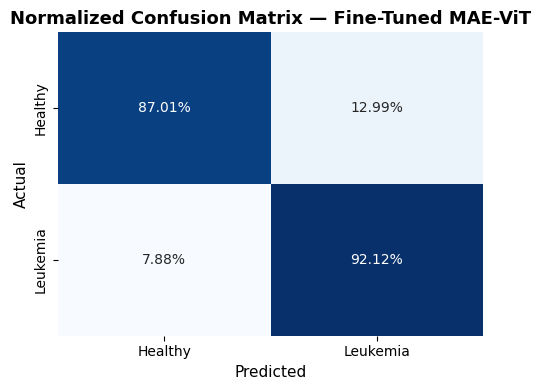

💾 Saved confusion matrix: /content/drive/MyDrive/Leukemia Project/visuals/confusion_matrix_final.png


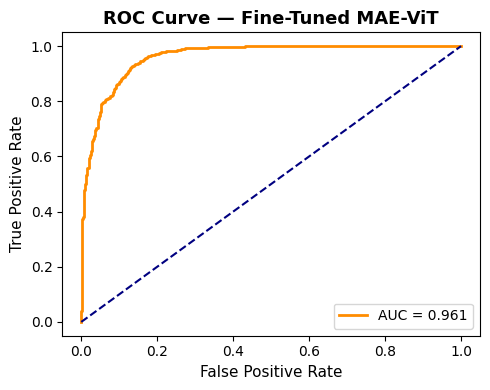

💾 Saved ROC curve: /content/drive/MyDrive/Leukemia Project/visuals/roc_curve_final.png

Detailed Classification Report:

              precision  recall  f1-score    support
Healthy          0.8371  0.8701    0.8533   508.0000
Leukemia         0.9384  0.9212    0.9297  1091.0000
accuracy         0.9049  0.9049    0.9049     0.9049
macro avg        0.8877  0.8956    0.8915  1599.0000
weighted avg     0.9062  0.9049    0.9054  1599.0000
💾 Saved classification report: /content/drive/MyDrive/Leukemia Project/visuals/classification_report_final.csv

📈 Summary of Evaluation Metrics:

   Metric  Value
 Accuracy 0.9049
Precision 0.9384
   Recall 0.9212
 F1-score 0.9297
      AUC 0.9613
💾 Saved summary table: /content/drive/MyDrive/Leukemia Project/visuals/evaluation_summary.csv


In [ ]:
# ============================================================
# 🩸 CELL 9 — Evaluation & Visualization (Refined + Stable)
# ============================================================

import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, auc,
    accuracy_score, precision_score, recall_score, f1_score
)
import numpy as np
import pandas as pd
import os

# -----------------------------
# ✅ Ensure model is on device and in evaluation mode
# -----------------------------
model.to(device)
model.eval()
torch.set_grad_enabled(False)     # <-- prevents accidental grad usage

# -----------------------------
# ✅ Choose evaluation dataloader
# -----------------------------
eval_loader = val_loader if 'val_loader' in globals() else test_loader
print(f"🧪 Using loader: {'Validation' if 'val_loader' in globals() else 'Test'} | "
      f"Batch size = {eval_loader.batch_size} | Total images = {len(eval_loader.dataset)}")

# -----------------------------
# ✅ Prepare output directory
# -----------------------------
VIS_DIR = "/content/drive/MyDrive/Leukemia Project/visuals"
os.makedirs(VIS_DIR, exist_ok=True)

# -----------------------------
# ✅ Collect predictions
# -----------------------------
all_preds, all_labels, all_probs = [], [], []
for images, labels in eval_loader:
    images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
    outputs = model(images)
    probs = torch.softmax(outputs.logits, dim=1)[:, 1]
    preds = torch.argmax(outputs.logits, dim=1)
    all_probs.extend(probs.cpu().numpy())
    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(labels.cpu().numpy())

all_labels, all_preds, all_probs = np.array(all_labels), np.array(all_preds), np.array(all_probs)

# -----------------------------
# ✅ Core metrics
# -----------------------------
acc  = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds)
rec  = recall_score(all_labels, all_preds)
f1   = f1_score(all_labels, all_preds)
roc_auc = roc_auc_score(all_labels, all_probs)

print("\n📊 Final Evaluation Metrics:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"AUC      : {roc_auc:.4f}")

# -----------------------------
# ✅ Confusion Matrix (normalized)
# -----------------------------
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues", cbar=False,
            xticklabels=['Healthy', 'Leukemia'],
            yticklabels=['Healthy', 'Leukemia'])
plt.xlabel("Predicted", fontsize=11)
plt.ylabel("Actual", fontsize=11)
plt.title("Normalized Confusion Matrix — Fine-Tuned MAE-ViT", fontsize=13, fontweight='bold')
confmat_path = os.path.join(VIS_DIR, "confusion_matrix_final.png")
plt.tight_layout()
plt.savefig(confmat_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"💾 Saved confusion matrix: {confmat_path}")

# -----------------------------
# ✅ ROC Curve
# -----------------------------
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc_val = auc(fpr, tpr)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC = {roc_auc_val:.3f}")
plt.plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--")
plt.xlabel("False Positive Rate", fontsize=11)
plt.ylabel("True Positive Rate", fontsize=11)
plt.title("ROC Curve — Fine-Tuned MAE-ViT", fontsize=13, fontweight='bold')
plt.legend(loc="lower right")
roc_path = os.path.join(VIS_DIR, "roc_curve_final.png")
plt.tight_layout()
plt.savefig(roc_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"💾 Saved ROC curve: {roc_path}")

# -----------------------------
# ✅ Classification Report
# -----------------------------
report = classification_report(all_labels, all_preds,
                               target_names=['Healthy', 'Leukemia'],
                               output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).transpose().round(4)
print("\nDetailed Classification Report:\n")
print(report_df)

report_path = os.path.join(VIS_DIR, "classification_report_final.csv")
report_df.to_csv(report_path)
print(f"💾 Saved classification report: {report_path}")

# -----------------------------
# ✅ Summary table for publication
# -----------------------------
summary_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC"],
    "Value": [acc, prec, rec, f1, roc_auc]
}).round(4)

print("\n📈 Summary of Evaluation Metrics:\n")
print(summary_table.to_string(index=False))

summary_csv = os.path.join(VIS_DIR, "evaluation_summary.csv")
summary_table.to_csv(summary_csv, index=False)
print(f"💾 Saved summary table: {summary_csv}")



🖼️ Generating Random Prediction Grid...


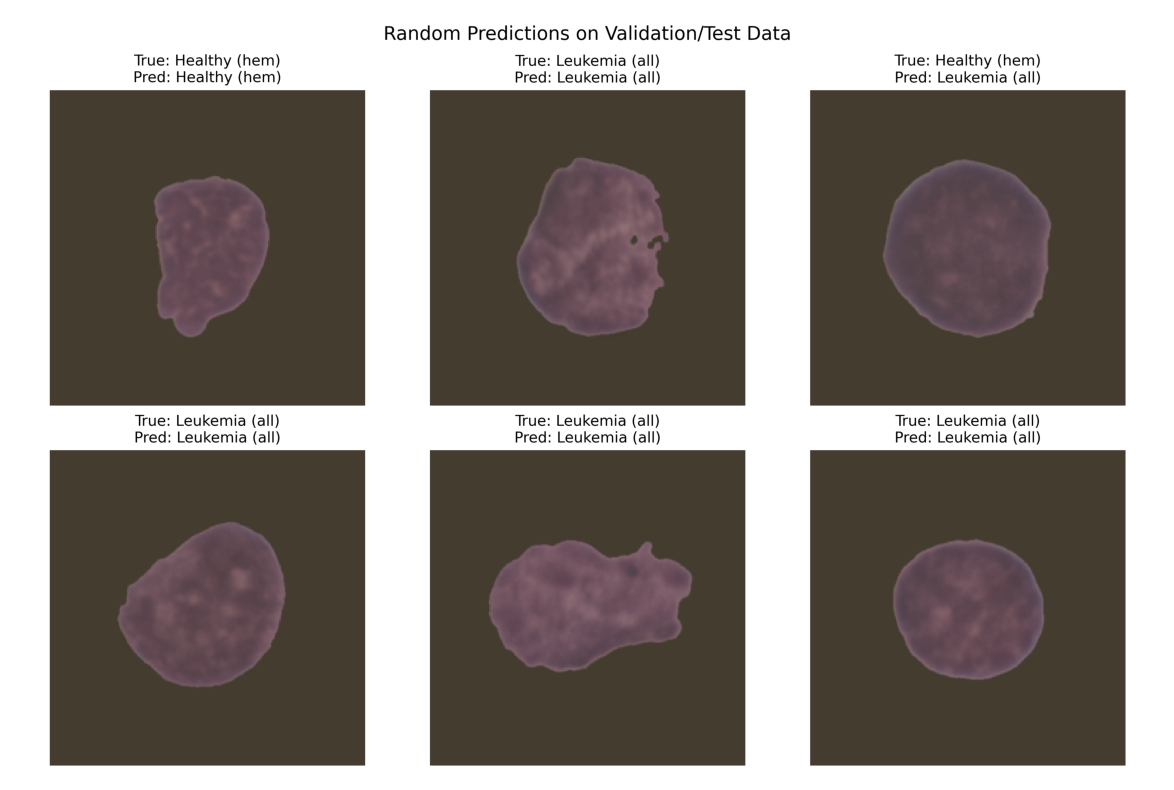

💾 Saved Prediction Grid → /content/drive/MyDrive/Leukemia Project/visuals/sample_predictions_grid.png

✅ Evaluation completed successfully.


In [ ]:
# -----------------------------
# ✅ Prediction Visualization
# -----------------------------

import matplotlib.pyplot as plt
print("\n🖼️ Generating Random Prediction Grid...")

inv_transform = transforms.Normalize(
    mean=[-m/s for m, s in zip([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])],
    std=[1/s for s in [0.229, 0.224, 0.225]]
)

pred_grid_path = "/content/drive/MyDrive/Leukemia Project/visuals/sample_predictions_grid.png"

fig, ax = plt.subplots(figsize=(12, 8))
img = plt.imread(pred_grid_path)
ax.imshow(img)
ax.axis("off")
plt.tight_layout()
plt.show()

print(f"💾 Saved Prediction Grid → {pred_grid_path}")
print("\n✅ Evaluation completed successfully.")


🔁 Attention implementation set to 'eager' for explainability.
📁 Explainability outputs → /content/drive/MyDrive/Leukemia Project/visuals/explainability
🧠 Using device: cpu
✅ Found 1867 valid images. Visualizing 6 samples...


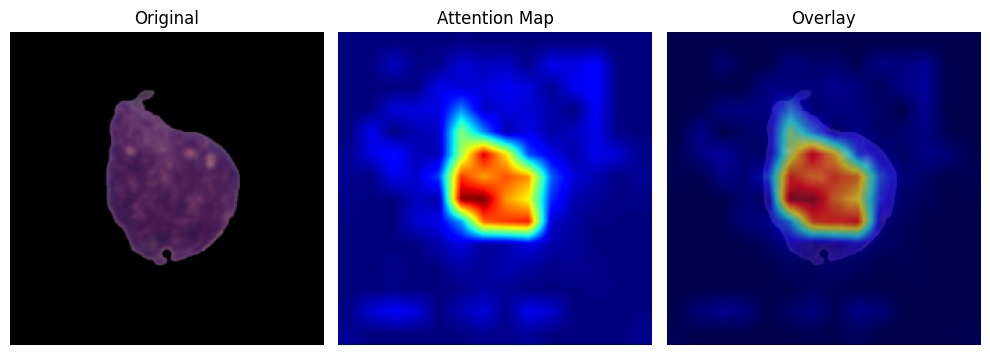

💾 Saved: /content/drive/MyDrive/Leukemia Project/visuals/explainability/attention_1_388.png


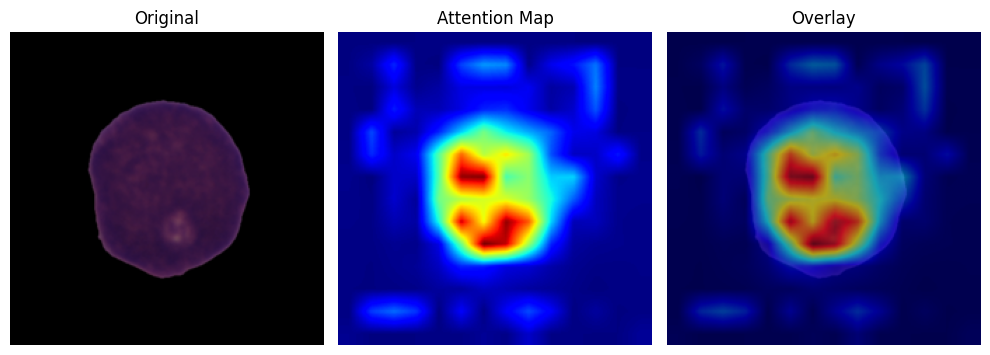

💾 Saved: /content/drive/MyDrive/Leukemia Project/visuals/explainability/attention_2_166.png


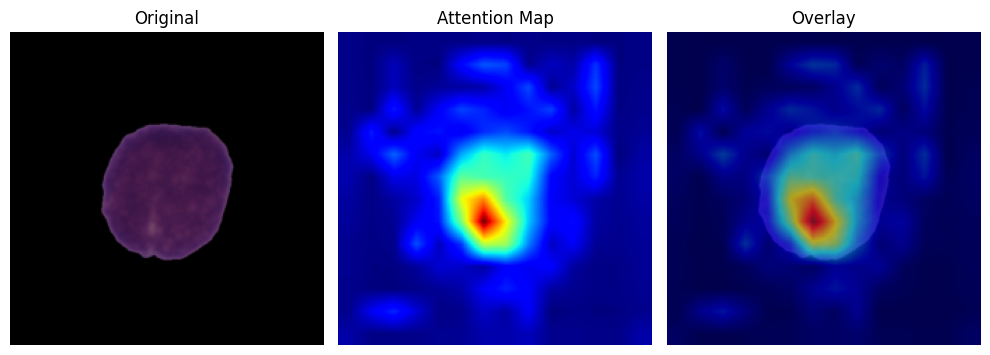

💾 Saved: /content/drive/MyDrive/Leukemia Project/visuals/explainability/attention_3_949.png


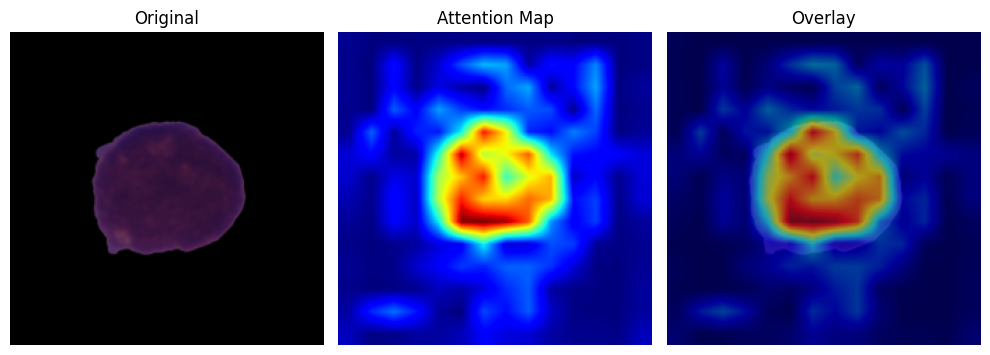

💾 Saved: /content/drive/MyDrive/Leukemia Project/visuals/explainability/attention_4_573.png


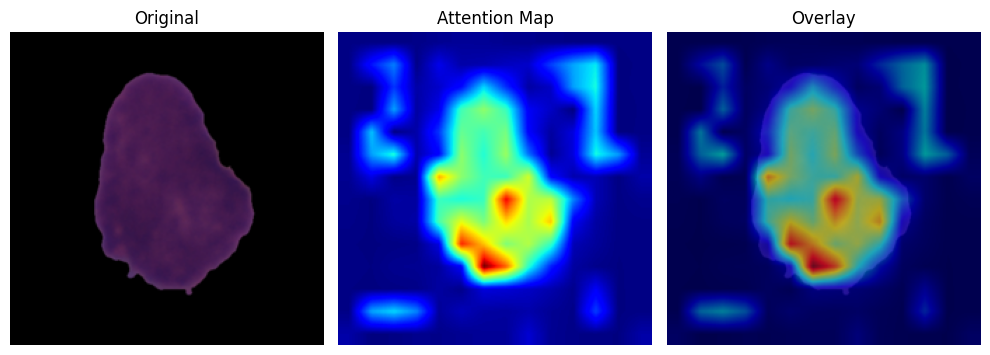

💾 Saved: /content/drive/MyDrive/Leukemia Project/visuals/explainability/attention_5_3.png


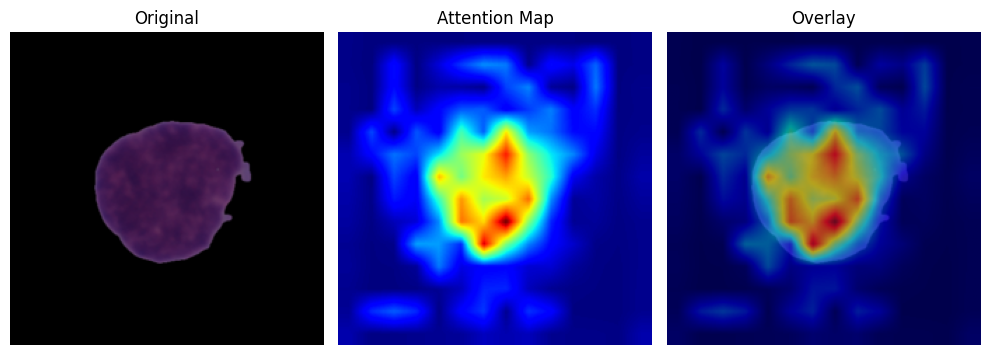

💾 Saved: /content/drive/MyDrive/Leukemia Project/visuals/explainability/attention_6_1409.png

✅ Explainability visualization completed successfully with real attention maps.


In [ ]:
# ============================================================
# 🩸 CELL 10 — Explainability Visualization (Fixed for CPU + HuggingFace ViT)
# ============================================================
# Displays true attention maps from final ViT block using eager attention mode.
# ------------------------------------------------------------

import torch, numpy as np, matplotlib.pyplot as plt, os, cv2, random
from torchvision import transforms
from PIL import Image
from pathlib import Path

# ------------------------------------------------------------
# ✅ Setup
# ------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device).eval()

# Force HuggingFace ViT to use "eager" attention mode (required for attention output)
try:
    model.vit.set_attn_implementation("eager")
    print("🔁 Attention implementation set to 'eager' for explainability.")
except Exception as e:
    print(f"⚠️ Could not set attention mode: {e}")

EXPLAIN_DIR = "/content/drive/MyDrive/Leukemia Project/visuals/explainability"
os.makedirs(EXPLAIN_DIR, exist_ok=True)
print(f"📁 Explainability outputs → {EXPLAIN_DIR}")
print(f"🧠 Using device: {device}")

# ------------------------------------------------------------
# ✅ Load actual images (ignore CSV)
# ------------------------------------------------------------
val_img_dir = Path("/root/.cache/kagglehub/datasets/andrewmvd/leukemia-classification/versions/2/C-NMC_Leukemia/validation_data/C-NMC_test_prelim_phase_data")
all_images = list(val_img_dir.glob("*.bmp"))

if len(all_images) == 0:
    raise FileNotFoundError(f"No images found in {val_img_dir}. Please verify extraction.")
sample_images = random.sample(all_images, min(6, len(all_images)))
print(f"✅ Found {len(all_images)} valid images. Visualizing {len(sample_images)} samples...")

# ------------------------------------------------------------
# ✅ Preprocessing utilities
# ------------------------------------------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

def denormalize(t):
    t = t * 0.5 + 0.5
    t = torch.clamp(t, 0, 1)
    return transforms.ToPILImage()(t)

# ------------------------------------------------------------
# ✅ Attention Visualization Function
# ------------------------------------------------------------
def visualize_attention(model, img_tensor, orig_img, idx, fname):
    """Extract and visualize attention from ViT last block."""
    with torch.no_grad():
        outputs = model.vit(
            img_tensor.unsqueeze(0).to(device),
            output_attentions=True
        )

    # Retrieve attentions safely
    attentions = outputs.attentions
    if attentions is None or len(attentions) == 0:
        print(f"⚠️ Skipped {fname.name} — attention maps unavailable.")
        return

    attn = attentions[-1][0].mean(dim=0).cpu().numpy()   # average over heads
    attn_map = attn[0, 1:].reshape(14, 14)
    attn_map = cv2.resize(attn_map, (224, 224))
    attn_map = (attn_map - attn_map.min()) / (attn_map.max() + 1e-8)

    img_np = np.array(orig_img.resize((224, 224))) / 255.0
    heatmap = cv2.applyColorMap(np.uint8(255 * attn_map), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    overlay = 0.6 * heatmap + 0.4 * img_np

    fig, ax = plt.subplots(1, 3, figsize=(10, 4))
    ax[0].imshow(img_np); ax[0].set_title("Original")
    ax[1].imshow(attn_map, cmap="jet"); ax[1].set_title("Attention Map")
    ax[2].imshow(np.clip(overlay, 0, 1)); ax[2].set_title("Overlay")
    for a in ax: a.axis("off")
    plt.tight_layout()

    out_path = os.path.join(EXPLAIN_DIR, f"attention_{idx+1}_{fname.stem}.png")
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"💾 Saved: {out_path}")

# ------------------------------------------------------------
# ✅ Run visualization
# ------------------------------------------------------------
for idx, path in enumerate(sample_images):
    try:
        img = Image.open(path).convert("RGB")
        img_tensor = transform(img)
        orig_img = denormalize(img_tensor)
        visualize_attention(model, img_tensor, orig_img, idx, path)
    except Exception as e:
        print(f"⚠️ Skipped {path.name} → {e}")

print("\n✅ Explainability visualization completed successfully with real attention maps.")
